# Forecast Characteristics -- Baseline vs DFL

Visualises what DFL training actually changes about the forecaster's OUTPUT quantiles --
not the downstream dispatch cost (that's `aggregate_results.ipynb`'s job), just the raw
forecast shape: median, spread (nested quantile bands), and alignment with the realised
trajectory.

One representative day per season is used (the day within that season whose total daily
prosumption is closest to the season's median -- avoids cherry-picking an unusual outlier
day). Seasons are meteorological (JJA/SON/DJF/MAM), pooled across the full test year
(2019-07-01..2020-06-30) regardless of which calendar year each month falls in.

Balanced archetype only (the only one trained now -- see `train_dfl_forecasts.py`'s
docstring). Two sections:
1. **Single-price**: baseline vs `dfl_1stage_single-price`.
2. **Dual-price**: baseline vs `dfl_1stage_dual-price`.

Fan-chart style: nested `fill_between` quantile bands (Q=19 levels -> 9 nested bands
around the median), median line, realised (dashed).

In [1]:
from __future__ import annotations
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from pyprojroot import here

sys.path.insert(0, str(here() / "8_testing"))
from eval_raw import (
    load_test_windows, forecast_quantiles, fresh_baseline_model, dfl_model_from,
    FORECASTING_DIR, DFL_TRAIN_DIR, QUANTILE_LEVELS,
)

## Load test windows + frozen baseline forecaster

In [2]:
print("loading test windows...")
windows = load_test_windows()

baseline_ckpt = torch.load(FORECASTING_DIR / "baseline_forecaster_best.pt", weights_only=False, map_location="cpu")
sc = baseline_ckpt["scaler_stats"]
baseline_model = fresh_baseline_model(baseline_ckpt)


def load_dfl(forecaster_id: str):
    dfl_ckpt = torch.load(DFL_TRAIN_DIR / f"{forecaster_id}.pt", weights_only=False, map_location="cpu")
    return dfl_model_from(baseline_ckpt, dfl_ckpt)


print(f"n_test_days={len(windows.delivery_start)}")

loading test windows...


[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)
n_test_days=366


## Representative day selection

One day per season: the day whose TOTAL daily realised prosumption is closest to that
season's median -- a plain, defensible notion of "representative", not an arbitrary fixed
calendar date that could land on an outlier (a storm day, a holiday, etc).

In [3]:
SEASON_MONTHS = {"spring": [3, 4, 5], "summer": [6, 7, 8], "autumn": [9, 10, 11], "winter": [12, 1, 2]}
SEASON_ORDER = ["spring", "summer", "autumn", "winter"]   # chronological through the test year


def representative_days(windows) -> dict:
    n = len(windows.delivery_start)
    daily_total = np.array([np.asarray(windows.y[d], float).sum() for d in range(n)])
    months = np.array([windows.delivery_start[d].month for d in range(n)])
    picks = {}
    for season, mo_list in SEASON_MONTHS.items():
        idx = np.where(np.isin(months, mo_list))[0]
        vals = daily_total[idx]
        median_val = np.median(vals)
        picks[season] = int(idx[np.argmin(np.abs(vals - median_val))])
    return picks


REP_DAYS = representative_days(windows)
for season in SEASON_ORDER:
    d = REP_DAYS[season]
    print(f"{season:8s} -> day {d:3d}  ({windows.delivery_start[d].date()})")

spring   -> day 269  (2020-03-26)
summer   -> day  10  (2019-07-11)
autumn   -> day 118  (2019-10-27)
winter   -> day 179  (2019-12-27)


## Fan-chart helper

In [4]:
def plot_fan(ax, quantiles, realised, title, color="C0", quantile_levels=QUANTILE_LEVELS):
    """Nested quantile-band fan chart: fill between symmetric quantile pairs (innermost
    to outermost), median line, realised dashed line."""
    qp = np.asarray(quantiles, dtype=float)     # (K, Q)
    y = np.asarray(realised, dtype=float)       # (K,)
    time_idx = np.arange(qp.shape[0])
    mid = len(quantile_levels) // 2
    for k in range(mid):
        ax.fill_between(time_idx, qp[:, k], qp[:, -1 - k], alpha=0.15, color=color)
    ax.plot(time_idx, qp[:, mid], color=color, label="median forecast")
    ax.plot(time_idx, y, "k--", label="realised")
    ax.set_xlabel("hour of horizon")
    ax.set_ylabel("prosumption (MW)")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

## Section 1 -- single-price, normal/balanced archetype

`baseline` vs `dfl_1stage_single-price` (the unsuffixed, balanced-trained checkpoint --
the "normal archetype" DFL model for this market). Forecast quantiles don't depend on the
battery archetype at all -- they're a pure function of the model weights + input features.
What DOES depend on archetype is WHICH checkpoint this is, since each archetype's DFL run
produced genuinely different fine-tuned weights from the same frozen baseline start.

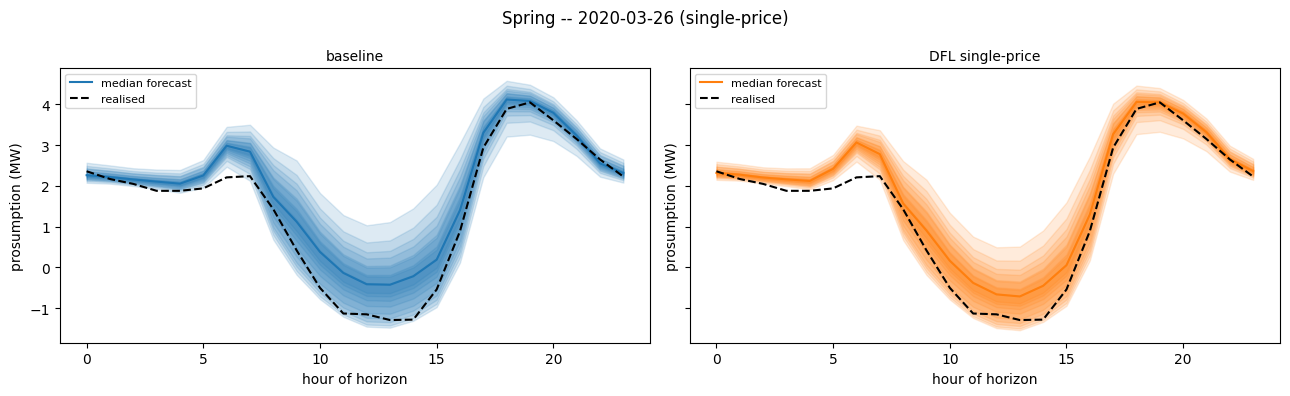

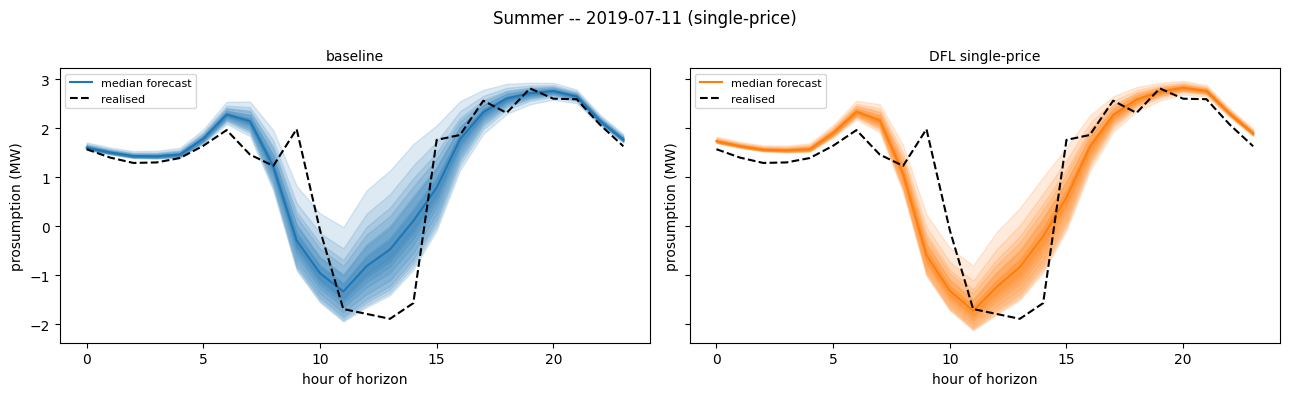

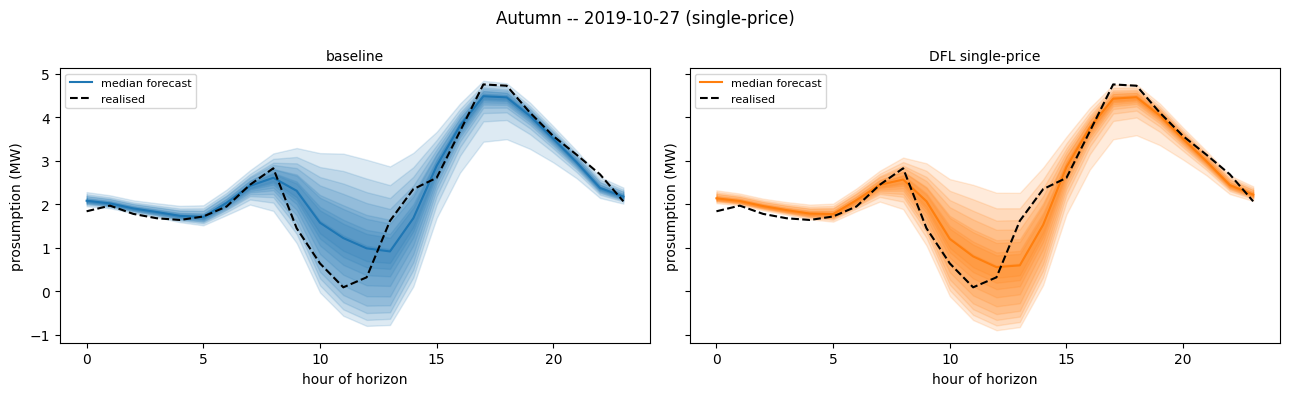

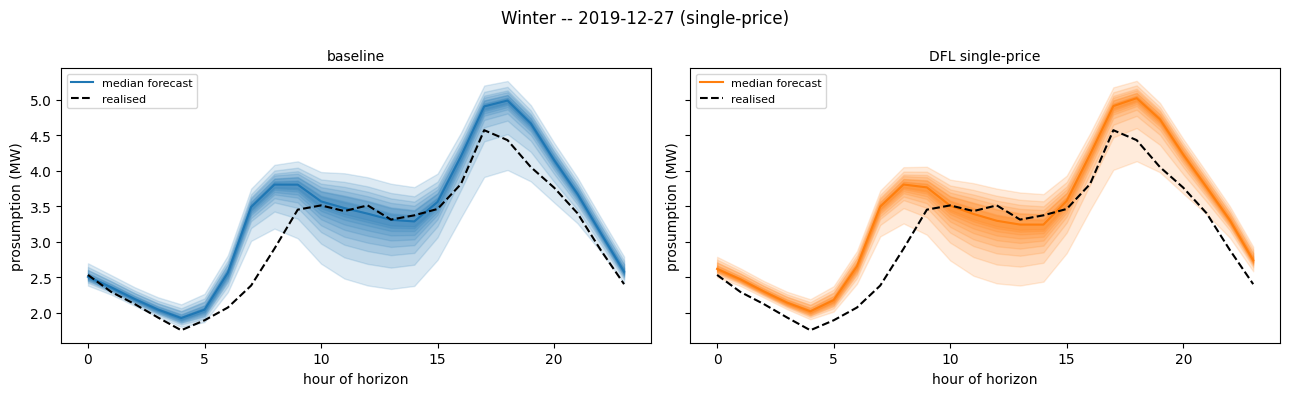

In [5]:
dfl_single = load_dfl("dfl_1stage_single-price")

for season in SEASON_ORDER:
    d = REP_DAYS[season]
    date = windows.delivery_start[d]
    realised = windows.y[d]
    x_hist, x_fut = windows.x_hist[d], windows.x_fut[d]

    q_base = forecast_quantiles(baseline_model, sc, x_hist, x_fut).detach().cpu().numpy()
    q_dfl = forecast_quantiles(dfl_single, sc, x_hist, x_fut).detach().cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
    plot_fan(axes[0], q_base, realised, "baseline", color="C0")
    plot_fan(axes[1], q_dfl, realised, "DFL single-price", color="C1")
    fig.suptitle(f"{season.capitalize()} -- {date.date()} (single-price)", fontsize=12)
    fig.tight_layout()
    plt.show()

## Section 2 -- dual-price

`baseline` vs `dfl_1stage_dual-price` (the balanced-trained DFL checkpoint). Same
representative days as Section 1 -- the day selection is market-agnostic (a property of
the realised prosumption series only, not of any forecaster).

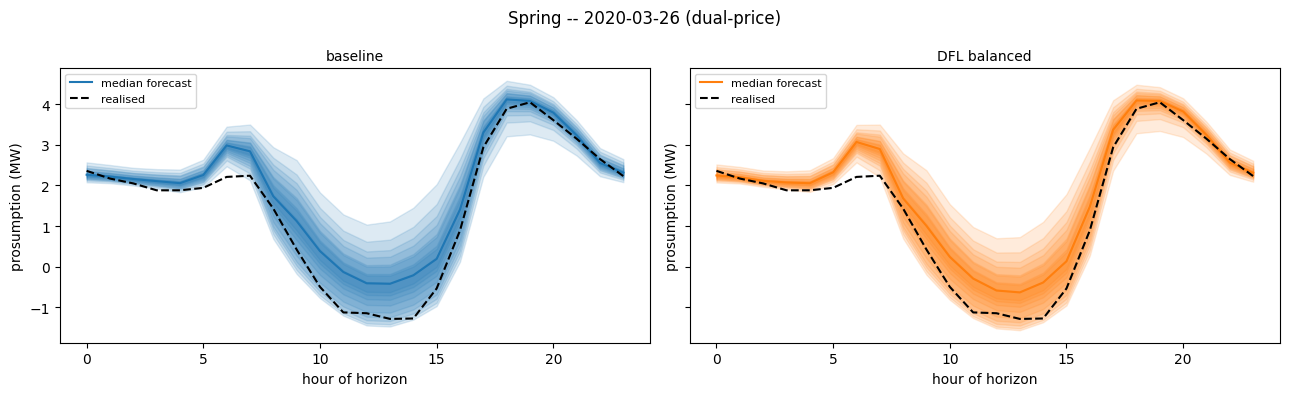

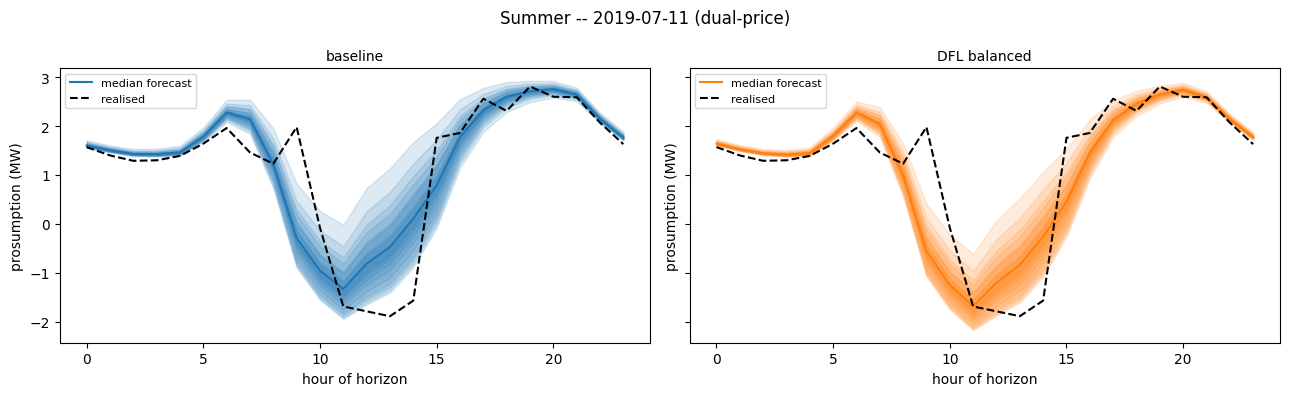

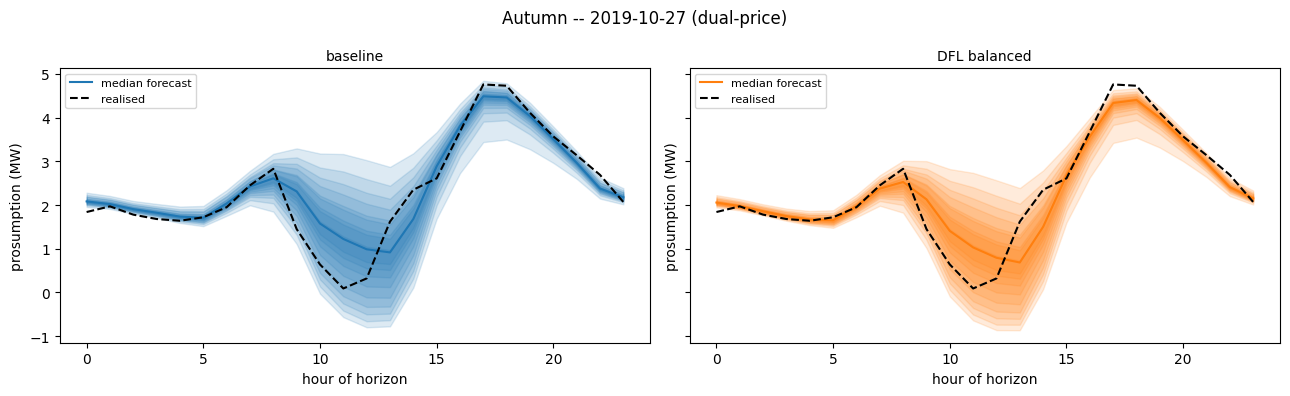

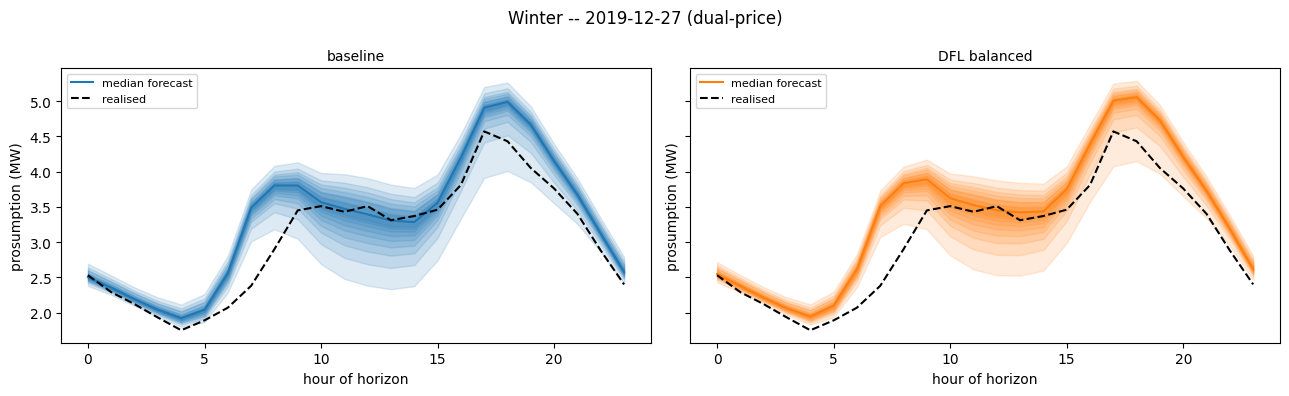

In [6]:
dual_forecasters = {
    "baseline": baseline_model,
    "DFL balanced": load_dfl("dfl_1stage_dual-price"),
}
dual_colors = {"baseline": "C0", "DFL balanced": "C1"}
dfl_dual_balanced = dual_forecasters["DFL balanced"]   # used throughout Sections 4b-10

for season in SEASON_ORDER:
    d = REP_DAYS[season]
    date = windows.delivery_start[d]
    realised = windows.y[d]
    x_hist, x_fut = windows.x_hist[d], windows.x_fut[d]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
    for ax, (label, model) in zip(axes, dual_forecasters.items()):
        q = forecast_quantiles(model, sc, x_hist, x_fut).detach().cpu().numpy()
        plot_fan(ax, q, realised, label, color=dual_colors[label])
    fig.suptitle(f"{season.capitalize()} -- {date.date()} (dual-price)", fontsize=12)
    fig.tight_layout()
    plt.show()

## Section 3 -- overlaying forecasts directly, and their explicit differences

Sections 1/2 show each forecaster in its own panel (bands included) so each one is
individually readable. This section puts multiple forecasters on the SAME axes instead,
for direct comparison -- two views, stacked:

- **Top panel**: every forecaster's MEDIAN line overlaid on one axes, plus realised.
  Bands are dropped here deliberately -- with 2-4 forecasters overlaid, nested
  `fill_between` regions would overlap into an unreadable smear; the median line alone is
  enough to compare shape/bias/timing directly.
- **Bottom panel**: each non-baseline forecaster's median MINUS the baseline's median, at
  every hour -- the literal, explicit "difference between forecasts" signal, with a zero
  reference line. Positive = that forecaster predicts higher prosumption than baseline at
  that hour; negative = lower.

Same representative days, same forecasters (`dfl_single`/`dual_forecasters`) already
loaded in Sections 1/2 -- no re-loading here.

In [7]:
def plot_overlay_and_delta(quantile_dict, realised, baseline_label, title, colors,
                            quantile_levels=QUANTILE_LEVELS):
    """quantile_dict: {label: (K, Q) array}. Top panel overlays every forecaster's MEDIAN
    line (no bands) plus realised. Bottom panel plots each non-baseline forecaster's
    median MINUS the baseline's median."""
    mid = len(quantile_levels) // 2
    time_idx = np.arange(next(iter(quantile_dict.values())).shape[0])
    medians = {label: q[:, mid] for label, q in quantile_dict.items()}
    y = np.asarray(realised, dtype=float)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                     gridspec_kw={"height_ratios": [2, 1]})

    for label, med in medians.items():
        ax1.plot(time_idx, med, color=colors[label], label=label, linewidth=1.8)
    ax1.plot(time_idx, y, "k--", label="realised", linewidth=1.5)
    ax1.set_ylabel("prosumption (MW)")
    ax1.set_title(title, fontsize=11)
    ax1.legend(fontsize=8, ncol=min(len(medians) + 1, 5))

    base_med = medians[baseline_label]
    for label, med in medians.items():
        if label == baseline_label:
            continue
        ax2.plot(time_idx, med - base_med, color=colors[label], label=f"{label} - {baseline_label}")
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_xlabel("hour of horizon")
    ax2.set_ylabel("Δ median (MW)")
    ax2.legend(fontsize=8)

    fig.tight_layout()
    plt.show()

### 3a -- single-price

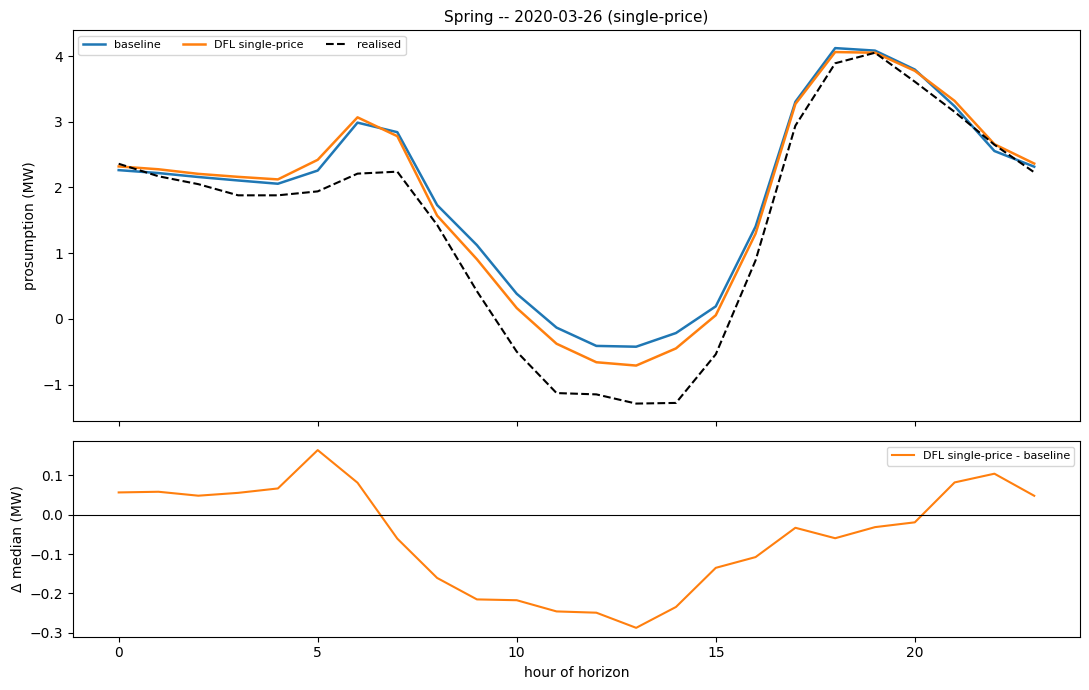

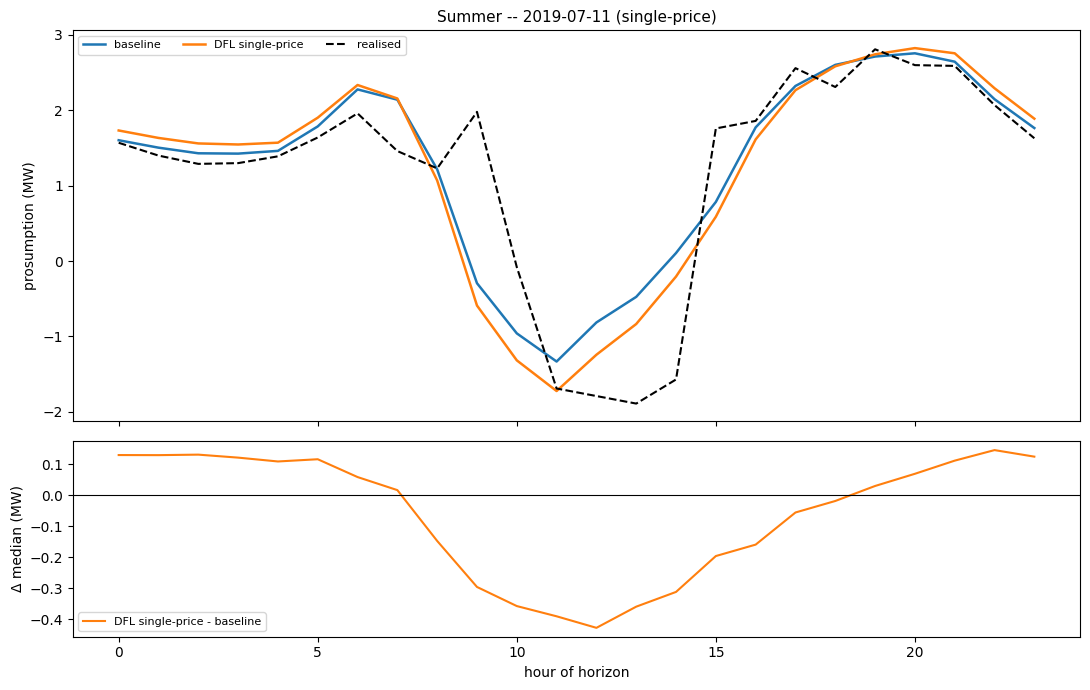

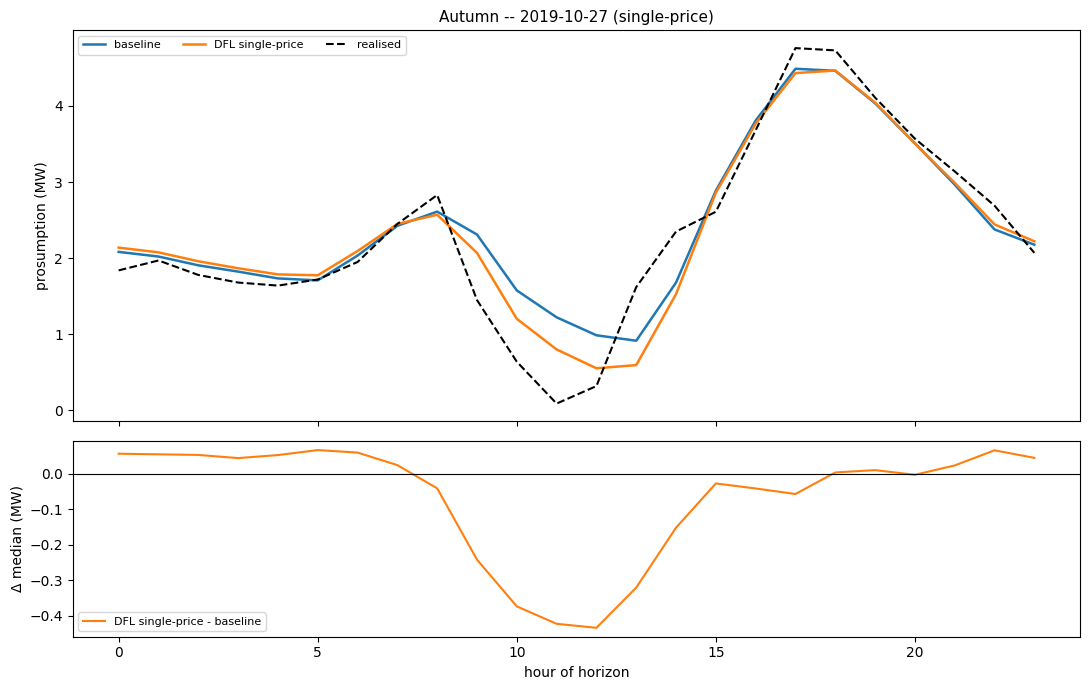

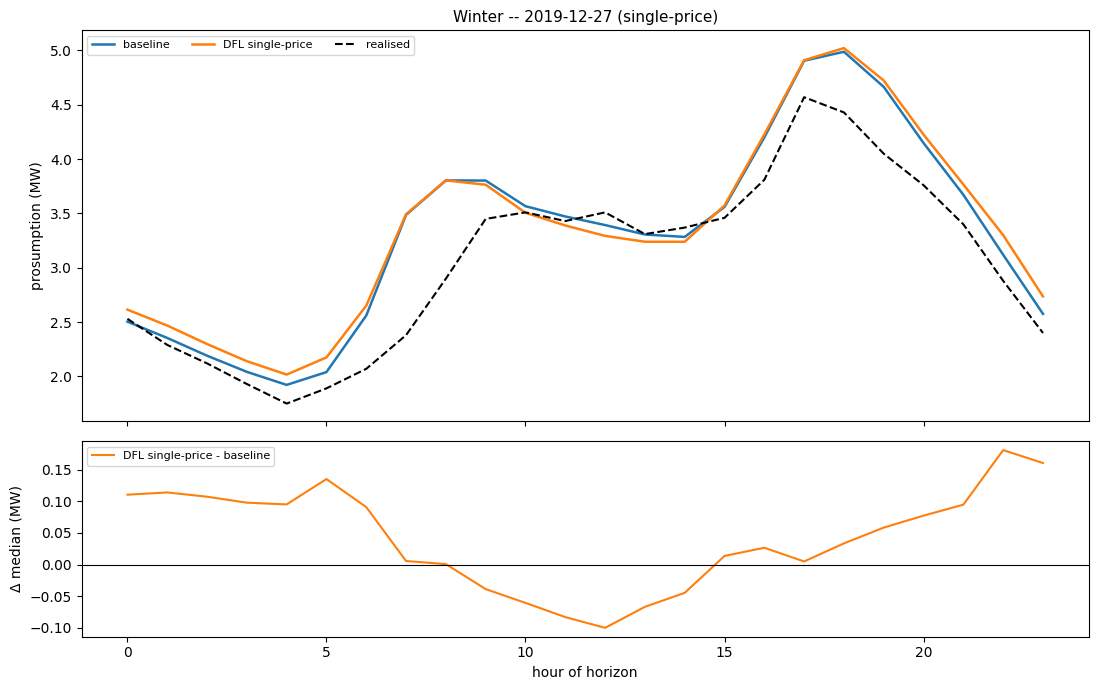

In [8]:
single_colors = {"baseline": "C0", "DFL single-price": "C1"}

for season in SEASON_ORDER:
    d = REP_DAYS[season]
    date = windows.delivery_start[d]
    realised = windows.y[d]
    x_hist, x_fut = windows.x_hist[d], windows.x_fut[d]

    q_base = forecast_quantiles(baseline_model, sc, x_hist, x_fut).detach().cpu().numpy()
    q_dfl = forecast_quantiles(dfl_single, sc, x_hist, x_fut).detach().cpu().numpy()

    plot_overlay_and_delta(
        {"baseline": q_base, "DFL single-price": q_dfl}, realised, "baseline",
        f"{season.capitalize()} -- {date.date()} (single-price)",
        colors=single_colors,
    )

### 3b -- dual-price

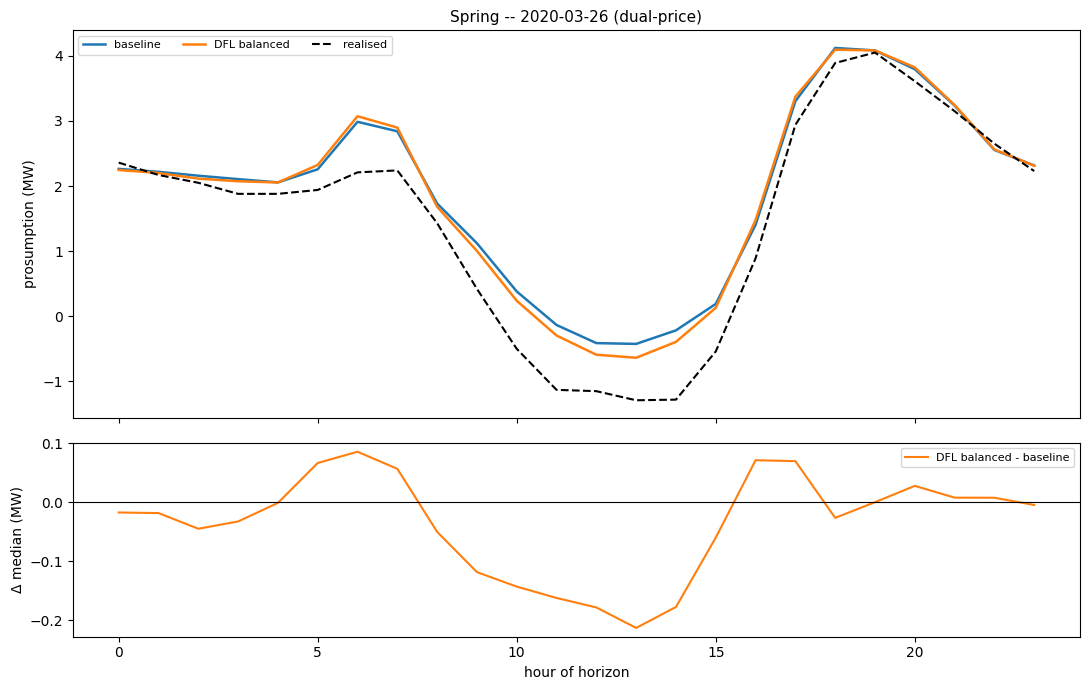

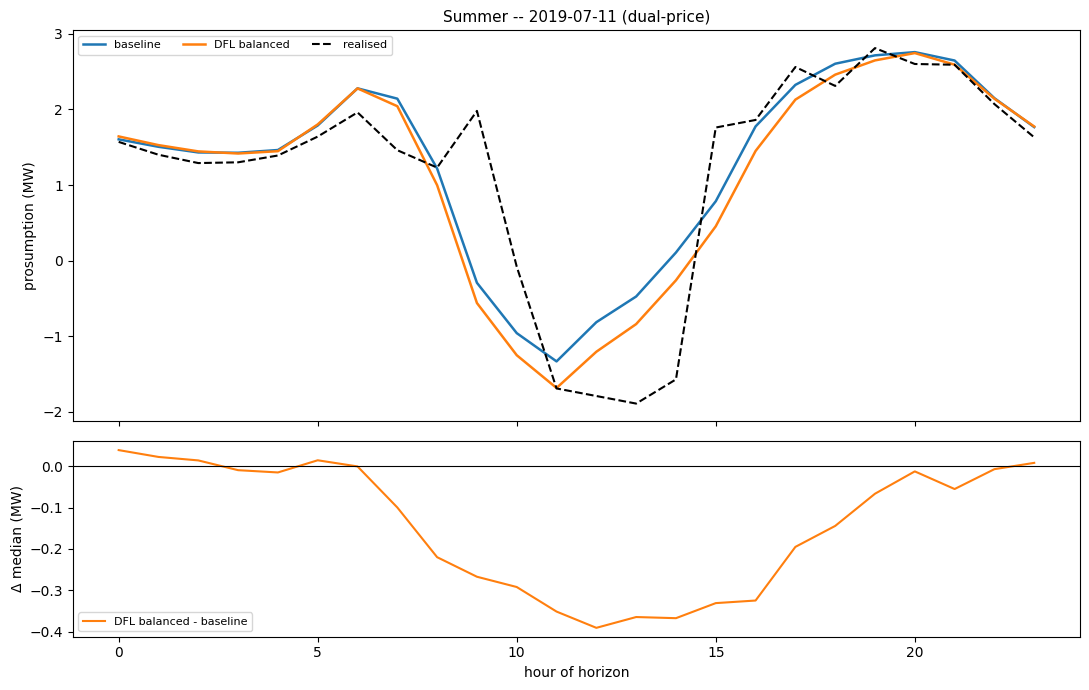

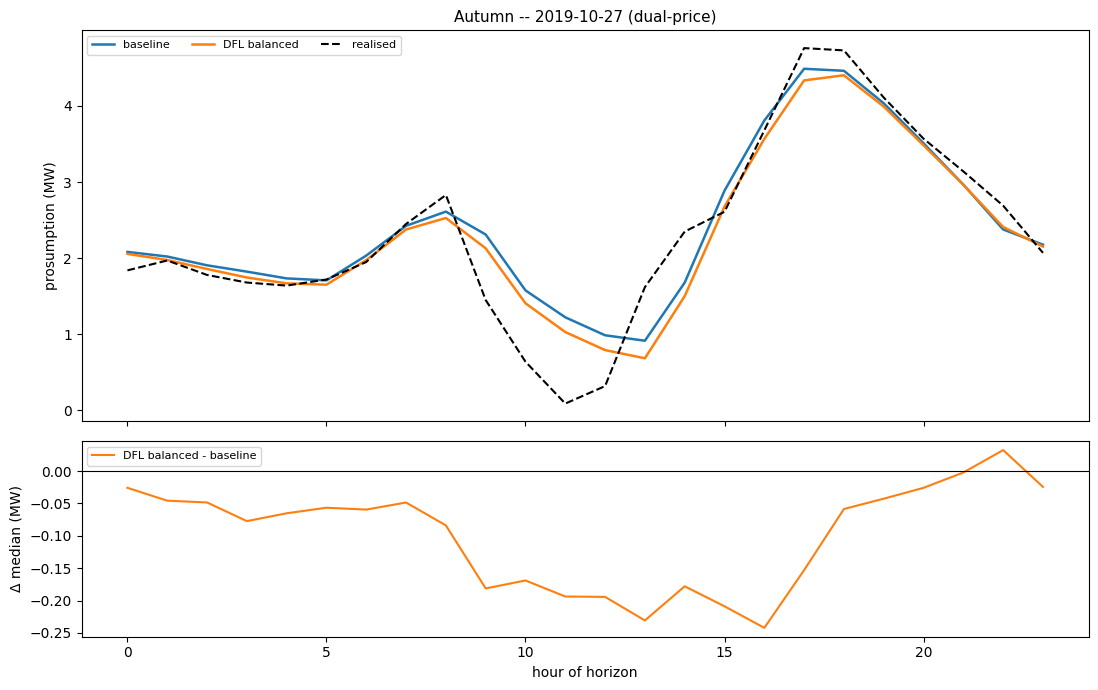

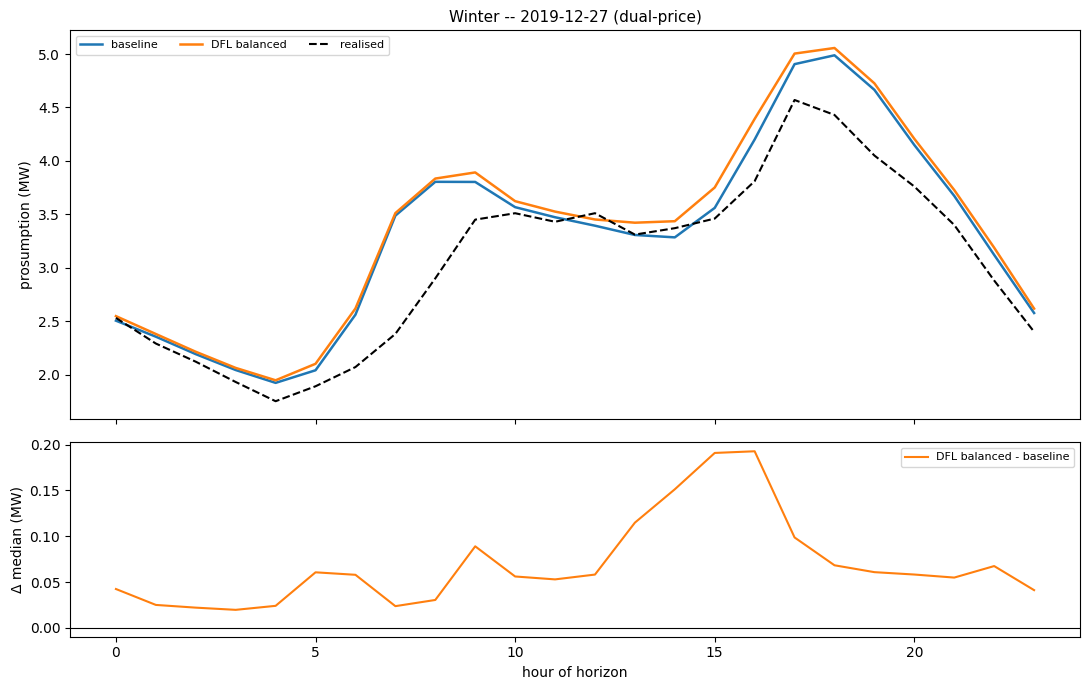

In [9]:
for season in SEASON_ORDER:
    d = REP_DAYS[season]
    date = windows.delivery_start[d]
    realised = windows.y[d]
    x_hist, x_fut = windows.x_hist[d], windows.x_fut[d]

    q_dict = {label: forecast_quantiles(model, sc, x_hist, x_fut).detach().cpu().numpy()
              for label, model in dual_forecasters.items()}

    plot_overlay_and_delta(
        q_dict, realised, "baseline",
        f"{season.capitalize()} -- {date.date()} (dual-price)",
        colors=dual_colors,
    )

## Section 4 -- band-overlay comparisons (baseline vs DFL)

A different style from Sections 1-3: instead of the full nested Q=19 fan (Section 1/2) or
bare median lines (Section 3), each panel here overlays exactly TWO forecasters' 15-85%
bands + medians + realised on one axes -- narrow enough bands, and few enough forecasters
per panel, that the overlap stays readable (unlike Section 3's median-only overlay, which
had to drop bands entirely once more than 2 forecasters were involved).

Layout mirrors a grid-of-panels-plus-one-shared-legend style: subplot TITLES carry which
comparison each panel shows, the legend (drawn once, at the bottom) stays generic
("baseline"/"DFL"). `box_lo`/`box_hi` default to `(0.15, 0.85)` -- the same locked-in box
level used throughout the rest of this project, not a new arbitrary choice.

**4a**: single-price, 2x2 grid (one panel per season) -- baseline vs DFL single-price.
**4b**: dual-price, 2x2 grid (one panel per season) -- baseline vs DFL dual-price.

In [10]:
def plot_band_overlay(ax, q_a, q_b, realised, label_a, label_b, color_a="C0", color_b="C1",
                       quantile_levels=QUANTILE_LEVELS, box_lo=0.15, box_hi=0.85, title=""):
    """Two forecasters' box_lo-box_hi bands + medians overlaid on one axes, plus
    realised. Draws only (never calls ax.legend()) -- the caller collects one shared
    legend across the whole grid, matching the reference figure's style."""
    levels = np.asarray(quantile_levels, float)
    i_lo = int(np.argmin(np.abs(levels - box_lo)))
    i_hi = int(np.argmin(np.abs(levels - box_hi)))
    mid = len(levels) // 2
    time_idx = np.arange(q_a.shape[0])
    y = np.asarray(realised, dtype=float)
    band_label = f"{int(box_lo * 100)}-{int(box_hi * 100)}%"

    ax.fill_between(time_idx, q_a[:, i_lo], q_a[:, i_hi], color=color_a, alpha=0.25,
                     label=f"{label_a} {band_label}")
    ax.plot(time_idx, q_a[:, mid], "--", color=color_a, label=f"{label_a} median")
    ax.fill_between(time_idx, q_b[:, i_lo], q_b[:, i_hi], color=color_b, alpha=0.25,
                     label=f"{label_b} {band_label}")
    ax.plot(time_idx, q_b[:, mid], "--", color=color_b, label=f"{label_b} median")
    ax.plot(time_idx, y, "k-o", markersize=3, linewidth=1.2, label="realised")

    ax.set_xlabel("hour")
    ax.set_ylabel("prosumption (MW)")
    if title:
        ax.set_title(title, fontsize=10)


def plot_band_grid(cells, nrows, ncols, suptitle, label_a="baseline", label_b="DFL",
                    color_a="C0", color_b="C1", figsize=None):
    """cells: list of (subplot_title, q_a, q_b, realised), length nrows*ncols. One
    shared legend at the bottom (built from the first panel's handles) instead of a
    legend per panel."""
    if figsize is None:
        figsize = (5.5 * ncols, 4.0 * nrows + 1)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    axes = np.atleast_2d(axes)
    handles = labels = None
    for ax, (title, q_a, q_b, realised) in zip(axes.flat, cells):
        plot_band_overlay(ax, q_a, q_b, realised, label_a, label_b, color_a, color_b, title=title)
        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

    fig.suptitle(suptitle, fontsize=13)
    fig.legend(handles, labels, loc="lower center", ncol=len(labels), fontsize=9, bbox_to_anchor=(0.5, -0.01))
    fig.tight_layout(rect=[0, 0.04, 1, 0.96])
    plt.show()

### 4a -- single-price

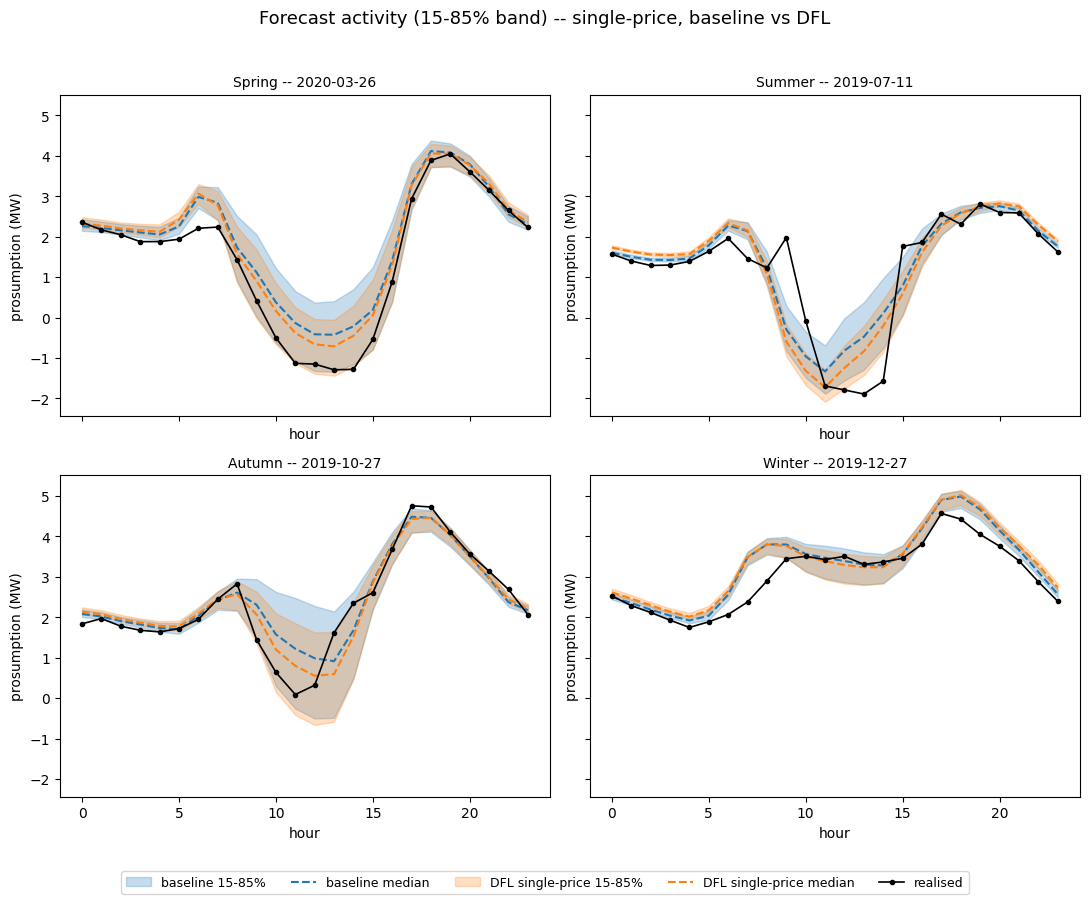

In [11]:
single_cells = []
for season in SEASON_ORDER:
    d = REP_DAYS[season]
    date = windows.delivery_start[d]
    realised = windows.y[d]
    x_hist, x_fut = windows.x_hist[d], windows.x_fut[d]

    q_base = forecast_quantiles(baseline_model, sc, x_hist, x_fut).detach().cpu().numpy()
    q_dfl = forecast_quantiles(dfl_single, sc, x_hist, x_fut).detach().cpu().numpy()
    single_cells.append((f"{season.capitalize()} -- {date.date()}", q_base, q_dfl, realised))

plot_band_grid(single_cells, nrows=2, ncols=2,
               suptitle="Forecast activity (15-85% band) -- single-price, baseline vs DFL",
               label_a="baseline", label_b="DFL single-price")

### 4b -- dual-price

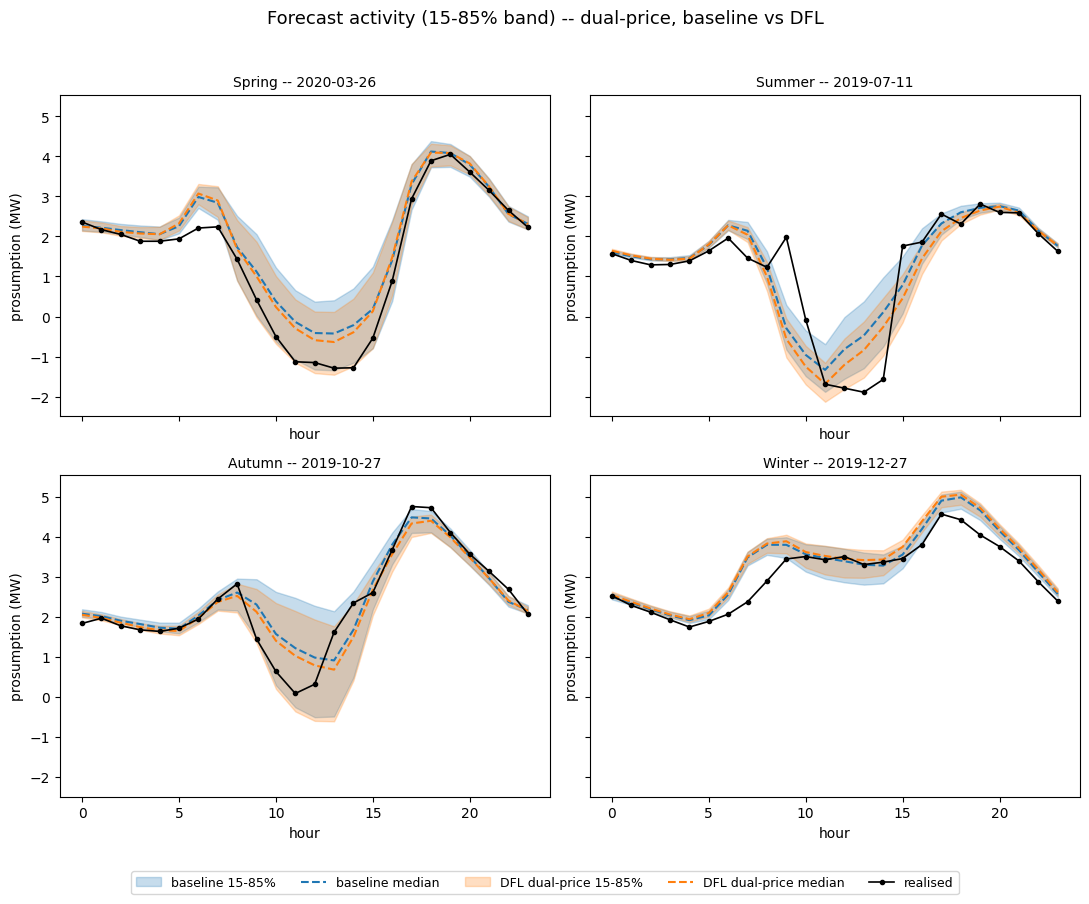

In [12]:
dual_cells = []
for season in SEASON_ORDER:
    d = REP_DAYS[season]
    date = windows.delivery_start[d]
    realised = windows.y[d]
    x_hist, x_fut = windows.x_hist[d], windows.x_fut[d]

    q_base = forecast_quantiles(baseline_model, sc, x_hist, x_fut).detach().cpu().numpy()
    q_dfl = forecast_quantiles(dfl_dual_balanced, sc, x_hist, x_fut).detach().cpu().numpy()
    dual_cells.append((f"{season.capitalize()} -- {date.date()}", q_base, q_dfl, realised))

plot_band_grid(dual_cells, nrows=2, ncols=2,
               suptitle="Forecast activity (15-85% band) -- dual-price, baseline vs DFL",
               label_a="baseline", label_b="DFL dual-price")

## Section 5 -- seasonal-average forecast activity

Complements Sections 1-4 rather than replacing them: those show ONE representative day
per season (concrete, plausible, but still a single day -- could show a forecaster-
specific quirk unique to that day). This section averages the quantile forecast
hour-by-hour across EVERY test day in a season, for each forecaster, to surface the
SYSTEMATIC shape/bias pattern instead -- does a forecaster consistently shift the median
at certain hours, consistently widen/narrow the band in the evening, etc, net of
day-to-day noise.

**Caveat worth being explicit about**: this averages quantile VALUES across days, not a
re-derived population quantile (mean-of-quantiles != quantile-of-the-mixture) -- fine for
reading off a "typical shape", but it means the "realised" line here is a MEAN DAILY
PROFILE (also averaged across the season's days), not one real day's ground truth. A cold
snap's peak and a mild day's peak land at different hours and get smoothed together, so
don't read this "realised" line as a calibration check the way Section 4's single-day
realised line is -- it's a seasonal-average reference shape only.

Same `plot_band_overlay`/`plot_band_grid` helpers as Section 4 (15-85% band style), same
season definitions/order -- only the per-day lookup is replaced with a per-season average.

In [13]:
SEASON_DAY_INDICES = {}
_n_days = len(windows.delivery_start)
_months = np.array([windows.delivery_start[d].month for d in range(_n_days)])
for season, mo_list in SEASON_MONTHS.items():
    SEASON_DAY_INDICES[season] = np.where(np.isin(_months, mo_list))[0]
    print(f"{season:8s}: {len(SEASON_DAY_INDICES[season])} days")


def seasonal_average_quantiles(model, day_indices):
    """Averages this forecaster's (K, Q) quantile forecast, and the (K,) realised
    trajectory, element-wise across every day index given."""
    q_list, y_list = [], []
    for d in day_indices:
        q = forecast_quantiles(model, sc, windows.x_hist[d], windows.x_fut[d]).detach().cpu().numpy()
        q_list.append(q)
        y_list.append(np.asarray(windows.y[d], float))
    return np.mean(q_list, axis=0), np.mean(y_list, axis=0)


# baseline is the SAME forecaster regardless of price_mode -- compute its seasonal
# average once per season, shared by both 5a and 5b below (not recomputed twice).
baseline_seasonal = {}
for season in SEASON_ORDER:
    q_mean, y_mean = seasonal_average_quantiles(baseline_model, SEASON_DAY_INDICES[season])
    baseline_seasonal[season] = (q_mean, y_mean)
print("baseline seasonal averages computed")

spring  : 92 days
summer  : 92 days
autumn  : 91 days
winter  : 91 days


baseline seasonal averages computed


### 5a -- single-price

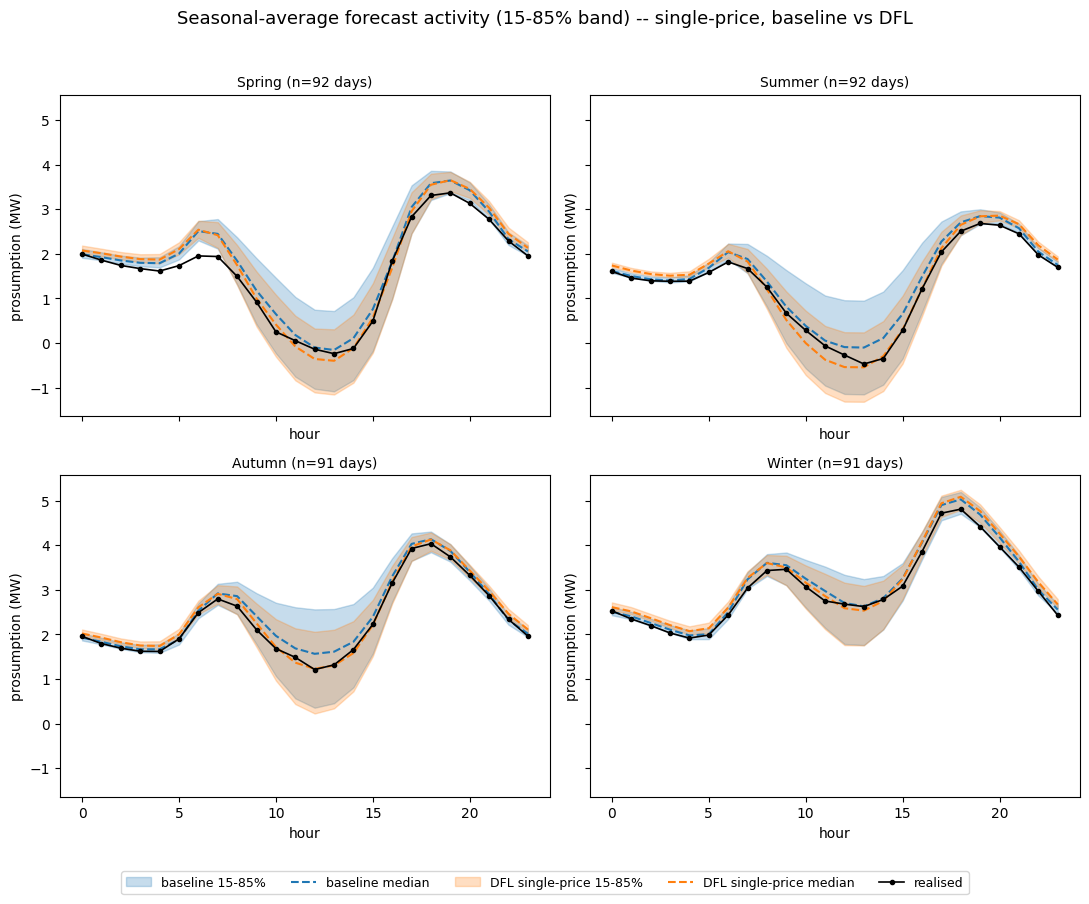

In [14]:
single_avg_cells = []
for season in SEASON_ORDER:
    q_base_mean, y_mean = baseline_seasonal[season]
    q_dfl_mean, _ = seasonal_average_quantiles(dfl_single, SEASON_DAY_INDICES[season])
    n_days = len(SEASON_DAY_INDICES[season])
    single_avg_cells.append((f"{season.capitalize()} (n={n_days} days)", q_base_mean, q_dfl_mean, y_mean))

plot_band_grid(single_avg_cells, nrows=2, ncols=2,
               suptitle="Seasonal-average forecast activity (15-85% band) -- single-price, baseline vs DFL",
               label_a="baseline", label_b="DFL single-price")

### 5b -- dual-price

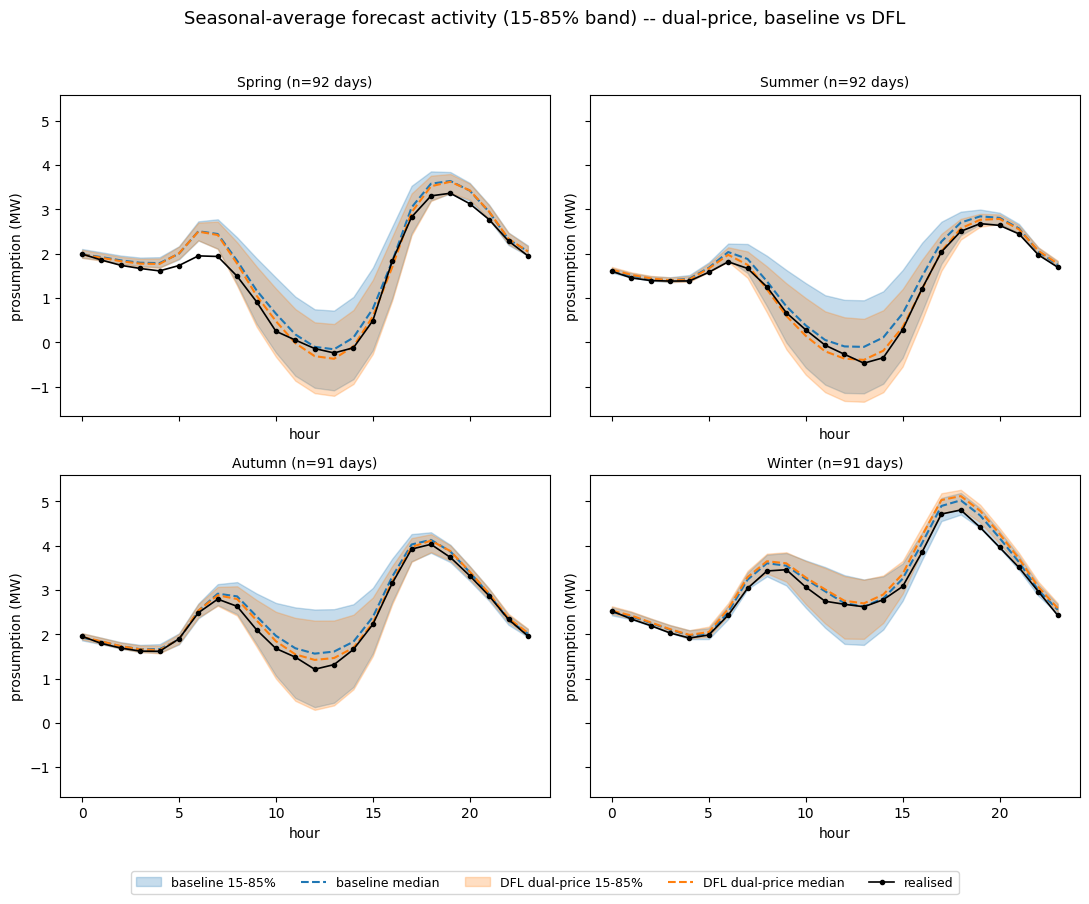

In [15]:
dual_avg_cells = []
for season in SEASON_ORDER:
    q_base_mean, y_mean = baseline_seasonal[season]
    q_dfl_mean, _ = seasonal_average_quantiles(dfl_dual_balanced, SEASON_DAY_INDICES[season])
    n_days = len(SEASON_DAY_INDICES[season])
    dual_avg_cells.append((f"{season.capitalize()} (n={n_days} days)", q_base_mean, q_dfl_mean, y_mean))

plot_band_grid(dual_avg_cells, nrows=2, ncols=2,
               suptitle="Seasonal-average forecast activity (15-85% band) -- dual-price, baseline vs DFL",
               label_a="baseline", label_b="DFL dual-price")

## Section 6 -- testing the mean-converges-to-median theory

Theory under test: DFL training pushes the forecaster's **mean** (`pl_hat`, the anchor
actually used in the dispatch/cost calculation) down so that it moves in line with the
forecaster's own **median** (the middle quantile output).

These are genuinely different quantities here, worth being precise about: `mean` comes
from `FrozenCopulaSampler.mean_and_errors` -- the sample mean of S copula-correlated
scenarios interpolated through the forecaster's OWN quantile function -- while `median` is
just `quantiles[:, mid]`, the raw Q=19 output at the middle quantile level. If the
forecaster's implied distribution is skewed at some hour, `mean` and `median` need not
coincide even for one internally-consistent forecaster -- that gap is exactly what the
theory says DFL training closes.

Uses the SAME seasonal-average day pools as Section 5 (`SEASON_DAY_INDICES`) -- this is a
systematic-bias question, not a single-day one, so averaging across each season's ~91
days is the right base rate here, not a representative day.

Two views per market:
- **Shape view**: mean (solid) and median (dashed) plotted directly, per forecaster --
  lets you see both curves and their gap by eye.
- **Gap view**: `mean - median` per hour, per forecaster, with a zero line -- the direct,
  quantitative test. If the theory holds, DFL's gap should sit closer to zero than
  baseline's gap.

In [16]:
import pickle
from eval_raw import COPULA_DIR, FrozenCopulaSampler

cop_bundle = pickle.load(open(COPULA_DIR / "frozen_copula.pkl", "rb"))
sampler = FrozenCopulaSampler(cop_bundle["Z_corr"], cop_bundle["quantile_levels"])
_MID = len(QUANTILE_LEVELS) // 2


def seasonal_average_mean_median(model, day_indices):
    """For each day: mean via sampler.mean_and_errors (sample mean of the forecaster's
    OWN implied distribution), median via the raw quantile output at the middle level.
    Averages both, element-wise, across every day index given -- linear, so this is
    equivalent to averaging the per-day (mean - median) gap directly."""
    mean_list, median_list = [], []
    for d in day_indices:
        q = forecast_quantiles(model, sc, windows.x_hist[d], windows.x_fut[d])   # (K, Q) torch
        mean, _ = sampler.mean_and_errors(q)
        mean_list.append(mean.detach().cpu().numpy())
        median_list.append(q[:, _MID].detach().cpu().numpy())
    return np.mean(mean_list, axis=0), np.mean(median_list, axis=0)

In [17]:
def plot_mean_median_shape(ax, forecaster_data, colors, title=""):
    """forecaster_data: {label: (mean (K,), median (K,))}. Mean solid, median dashed,
    same color per forecaster -- the gap is the vertical distance between same-colored
    lines."""
    for label, (mean, median) in forecaster_data.items():
        time_idx = np.arange(len(mean))
        ax.plot(time_idx, mean, "-", color=colors[label], label=f"{label} mean", linewidth=1.8)
        ax.plot(time_idx, median, "--", color=colors[label], label=f"{label} median", linewidth=1.3, alpha=0.85)
    ax.set_xlabel("hour")
    ax.set_ylabel("prosumption (MW)")
    if title:
        ax.set_title(title, fontsize=10)


def plot_mean_median_gap(ax, forecaster_data, colors, title=""):
    """forecaster_data: {label: (mean (K,), median (K,))}. Plots (mean - median) per
    forecaster with a zero reference line -- the direct quantitative test."""
    for label, (mean, median) in forecaster_data.items():
        time_idx = np.arange(len(mean))
        ax.plot(time_idx, mean - median, "-", color=colors[label], label=f"{label} mean-median", linewidth=1.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("hour")
    ax.set_ylabel("mean - median (MW)")
    if title:
        ax.set_title(title, fontsize=10)


def plot_grid(plot_fn, cells, nrows, ncols, suptitle, colors, figsize=None):
    """cells: list of (title, forecaster_data) -- forecaster_data as required by
    plot_fn. One shared legend at the bottom, same pattern as plot_band_grid."""
    if figsize is None:
        figsize = (5.5 * ncols, 4.0 * nrows + 1)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    axes = np.atleast_2d(axes)
    handles = labels = None
    for ax, (title, forecaster_data) in zip(axes.flat, cells):
        plot_fn(ax, forecaster_data, colors, title=title)
        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

    fig.suptitle(suptitle, fontsize=13)
    fig.legend(handles, labels, loc="lower center", ncol=min(len(labels), 6), fontsize=9, bbox_to_anchor=(0.5, -0.01))
    fig.tight_layout(rect=[0, 0.05, 1, 0.96])
    plt.show()

### 6a -- single-price

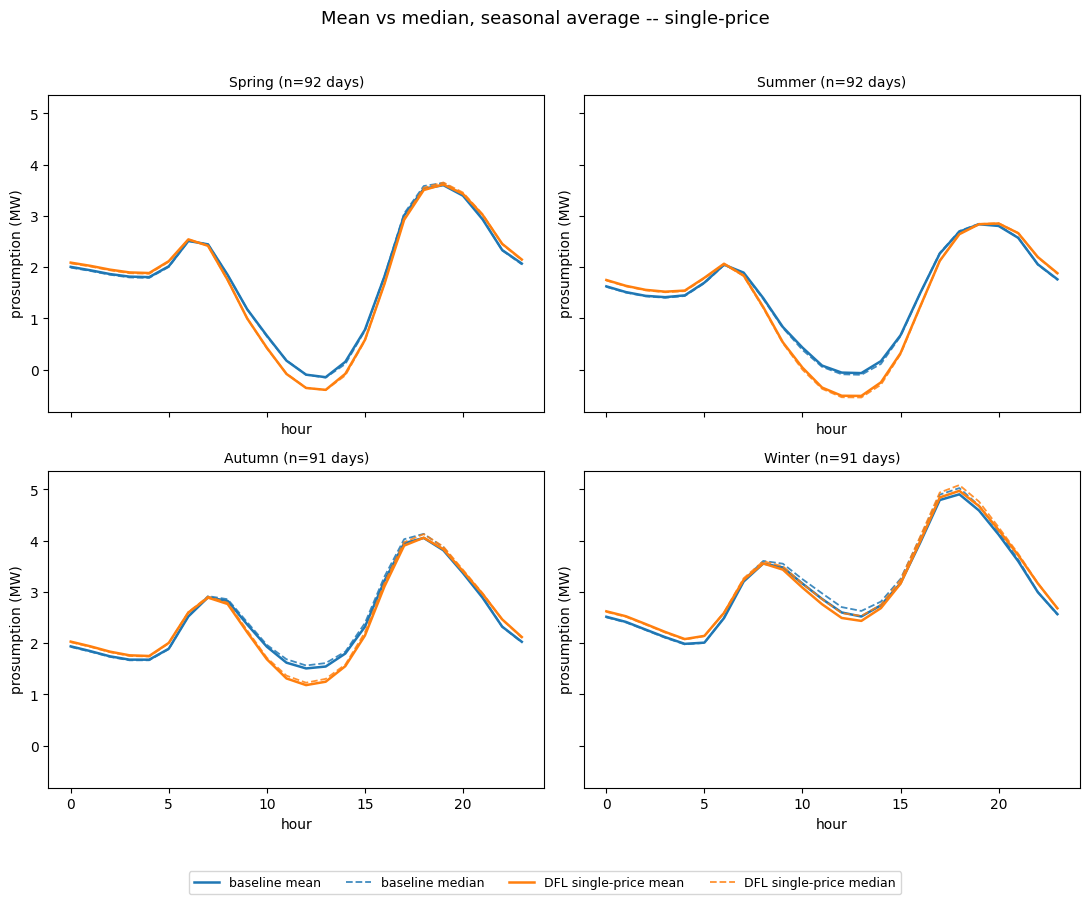

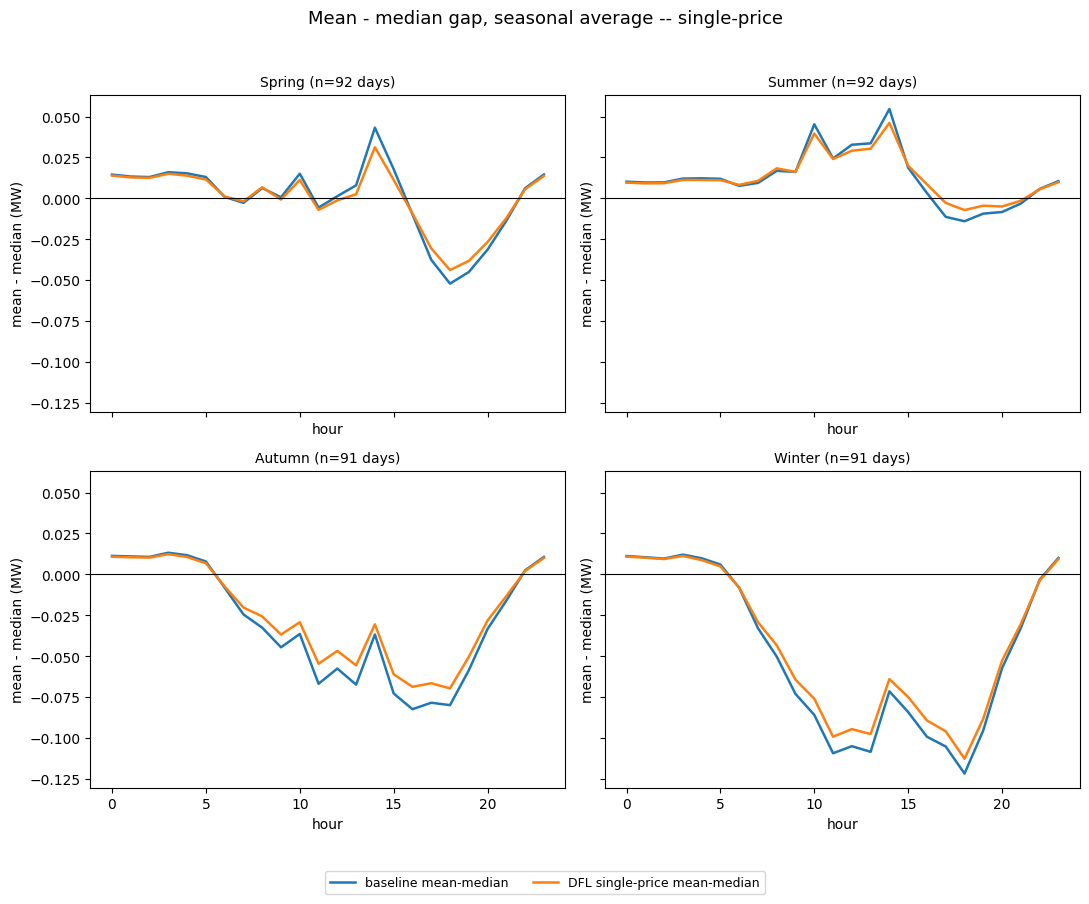

In [18]:
single_mm_colors = {"baseline": "C0", "DFL single-price": "C1"}

single_shape_cells, single_gap_cells = [], []
for season in SEASON_ORDER:
    n_days = len(SEASON_DAY_INDICES[season])
    mean_base, median_base = seasonal_average_mean_median(baseline_model, SEASON_DAY_INDICES[season])
    mean_dfl, median_dfl = seasonal_average_mean_median(dfl_single, SEASON_DAY_INDICES[season])

    data = {"baseline": (mean_base, median_base), "DFL single-price": (mean_dfl, median_dfl)}
    title = f"{season.capitalize()} (n={n_days} days)"
    single_shape_cells.append((title, data))
    single_gap_cells.append((title, data))

plot_grid(plot_mean_median_shape, single_shape_cells, nrows=2, ncols=2,
          suptitle="Mean vs median, seasonal average -- single-price", colors=single_mm_colors)
plot_grid(plot_mean_median_gap, single_gap_cells, nrows=2, ncols=2,
          suptitle="Mean - median gap, seasonal average -- single-price", colors=single_mm_colors)

### 6b -- dual-price

Same shape + gap views as 6a, baseline vs DFL dual-price.

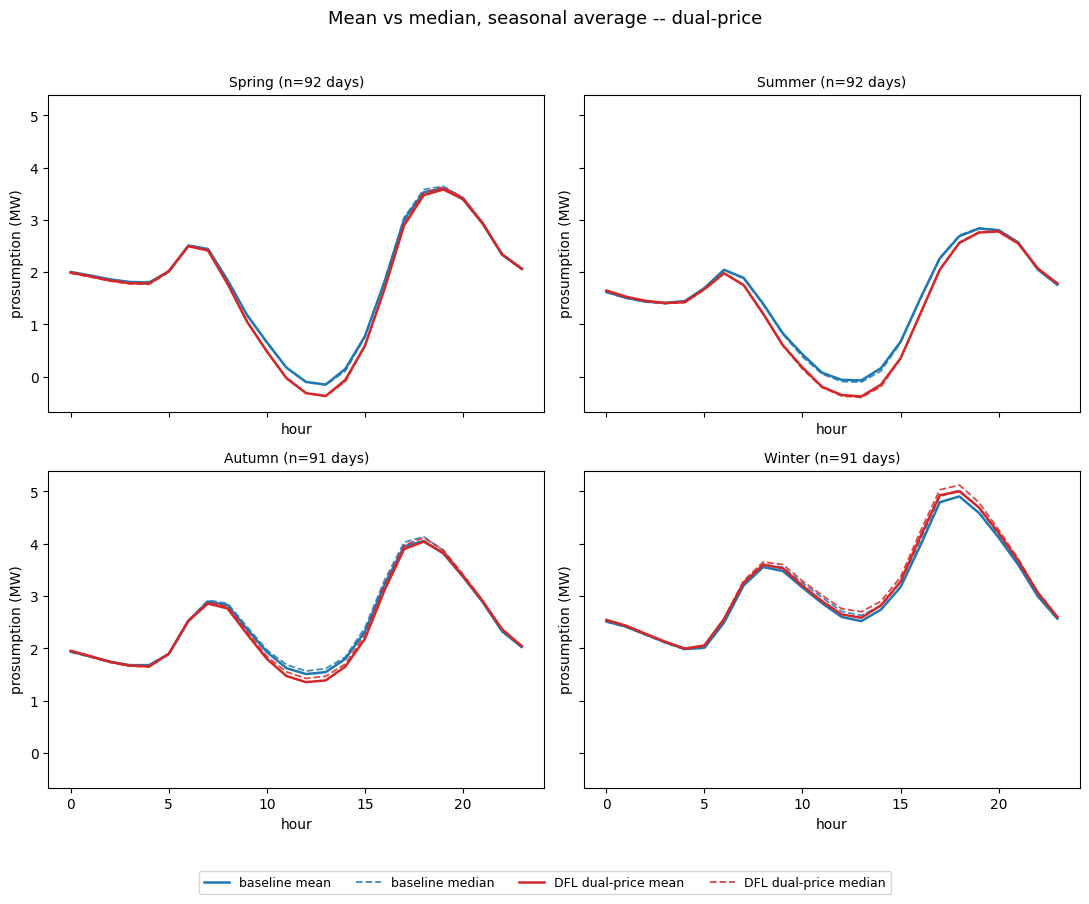

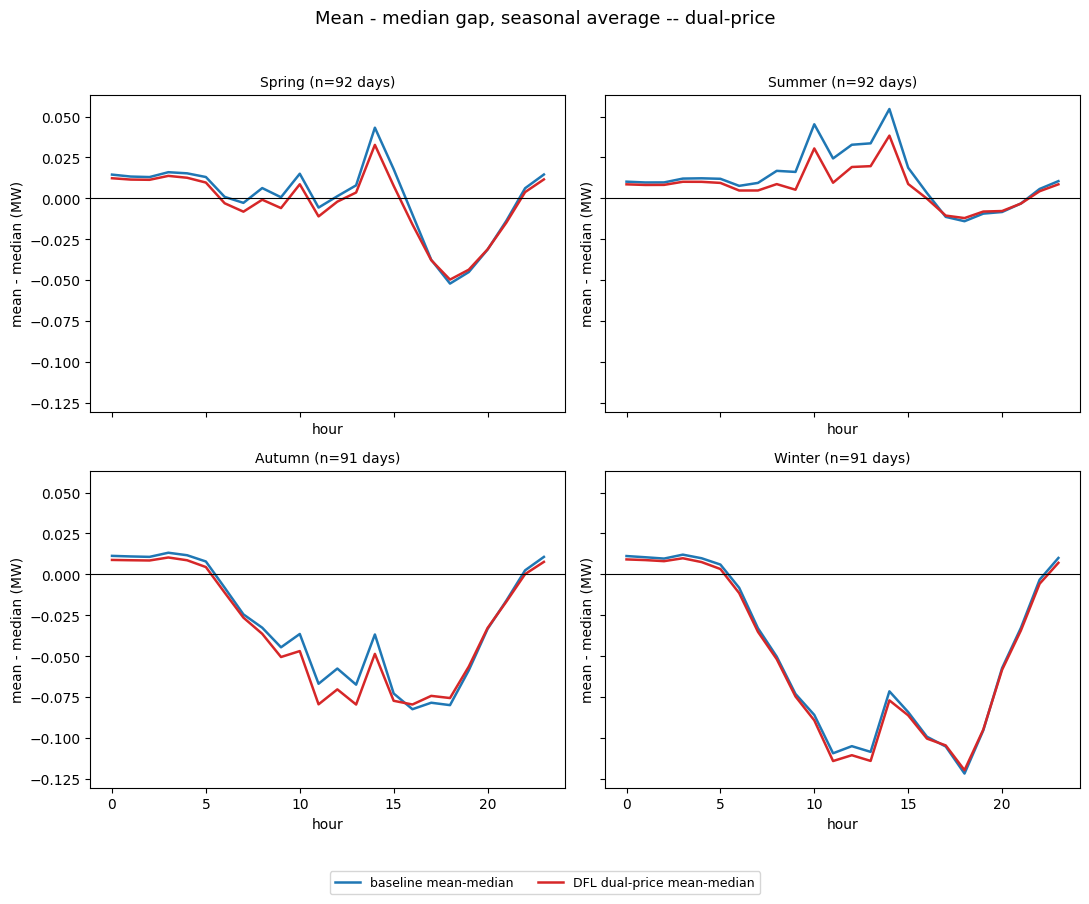

In [19]:
dual_mm_colors = {"baseline": "C0", "DFL dual-price": "C3"}

dual_shape_cells, dual_gap_cells = [], []
for season in SEASON_ORDER:
    n_days = len(SEASON_DAY_INDICES[season])
    mean_base, median_base = seasonal_average_mean_median(baseline_model, SEASON_DAY_INDICES[season])
    mean_dfl, median_dfl = seasonal_average_mean_median(dfl_dual_balanced, SEASON_DAY_INDICES[season])

    data = {"baseline": (mean_base, median_base), "DFL dual-price": (mean_dfl, median_dfl)}
    title = f"{season.capitalize()} (n={n_days} days)"
    dual_shape_cells.append((title, data))
    dual_gap_cells.append((title, data))

plot_grid(plot_mean_median_shape, dual_shape_cells, nrows=2, ncols=2,
          suptitle="Mean vs median, seasonal average -- dual-price", colors=dual_mm_colors)
plot_grid(plot_mean_median_gap, dual_gap_cells, nrows=2, ncols=2,
          suptitle="Mean - median gap, seasonal average -- dual-price", colors=dual_mm_colors)

## Section 7 -- does solar generation timing explain the midday bias?

Section 6 found the mean-median theory only weakly supported and flagged solar timing as
a stronger candidate: the DFL bias trough (hours ~10-14) lines up with peak solar
irradiance far better than with the day-ahead/imbalance price spread. This section checks
that directly: per-hour-of-day (averaged across every test day, same systematic-pattern
reasoning as Sections 5/6), compare `bias = mean_dfl - mean_baseline` against
`solar_irrad`, and check whether DFL's bias also makes the forecast more ACCURATE
specifically at the hours it shifts hardest (not just correlated in shape).

Three panels per market:
1. **Bias vs solar irradiance by hour** (twin axis) -- shape comparison.
2. **Scatter + linear fit** of `solar_irrad` against `bias`, R² annotated -- the direct
   quantitative test (compare against Section 6's price-spread R²=0.29).
3. **\|realised - mean\| by hour**, baseline vs DFL -- does the bias actually correct
   baseline's accuracy at these hours, or just move it?

7a/7b's tables/plots use the original seed (20240801) only, as a representative
illustration. Each subsection also reports the same R² **across all 5 seeds**
(`solar_r2_across_seeds`) -- this project's headline mechanism number, previously
reported as a single-seed R^2~0.93-0.96, is exactly the kind of quantity the ablation
sign-reversal (`why_dfl_helps.md` Section 5) already showed can be unstable to training
specifics; this is the direct check of whether that instability extends to the seed axis
too.

In [20]:
import pandas as pd
from eval_raw import DATA_DIR

raw_features = pd.read_csv(DATA_DIR / "df_full.csv", parse_dates=["datetime"]).set_index("datetime")


def hourly_bias_solar_table(model_a, model_b, label_a="baseline", label_b="DFL", day_indices=None):
    """Per-hour-of-day table, averaged across `day_indices` (default: every test day):
    realised, solar_irrad, each forecaster's mean (via sampler.mean_and_errors), the
    bias (mean_b - mean_a), and each forecaster's |error| vs realised."""
    if day_indices is None:
        day_indices = range(len(windows.delivery_start))

    bias_h = [[] for _ in range(24)]
    solar_h = [[] for _ in range(24)]
    realised_h = [[] for _ in range(24)]
    mean_a_h = [[] for _ in range(24)]
    mean_b_h = [[] for _ in range(24)]

    for d in day_indices:
        date = pd.Timestamp(windows.delivery_start[d])
        hours = pd.date_range(date, periods=24, freq="1h")
        if not hours.isin(raw_features.index).all():
            continue
        solar = raw_features.loc[hours, "solar_irrad"].to_numpy()
        realised = np.asarray(windows.y[d], float)

        q_a = forecast_quantiles(model_a, sc, windows.x_hist[d], windows.x_fut[d])
        q_b = forecast_quantiles(model_b, sc, windows.x_hist[d], windows.x_fut[d])
        mean_a, _ = sampler.mean_and_errors(q_a)
        mean_b, _ = sampler.mean_and_errors(q_b)
        mean_a = mean_a.detach().cpu().numpy()
        mean_b = mean_b.detach().cpu().numpy()

        for h in range(24):
            bias_h[h].append(mean_b[h] - mean_a[h])
            solar_h[h].append(solar[h])
            realised_h[h].append(realised[h])
            mean_a_h[h].append(mean_a[h])
            mean_b_h[h].append(mean_b[h])

    df = pd.DataFrame({
        "hour": range(24),
        "realised": [np.mean(r) for r in realised_h],
        "solar_irrad": [np.mean(s) for s in solar_h],
        f"mean_{label_a}": [np.mean(m) for m in mean_a_h],
        f"mean_{label_b}": [np.mean(m) for m in mean_b_h],
        "bias": [np.mean(b) for b in bias_h],
    }).set_index("hour")
    df[f"abs_err_{label_a}"] = (df["realised"] - df[f"mean_{label_a}"]).abs()
    df[f"abs_err_{label_b}"] = (df["realised"] - df[f"mean_{label_b}"]).abs()
    return df


def plot_solar_bias_analysis(df, label_a, label_b, suptitle):
    """label_a/label_b must match what built `df` (hourly_bias_solar_table's own
    label_a/label_b) -- "bias" is always mean_b - mean_a, and every panel now states
    that explicitly (axis label and/or legend) rather than relying on the caller to
    remember the convention or on the figure suptitle alone."""
    bias_label = f"{label_b} - {label_a}"
    fig, axes = plt.subplots(1, 3, figsize=(19, 5))

    ax1 = axes[0]
    line_bias, = ax1.plot(df.index, df["bias"], "-o", color="C1", markersize=3, label=f"bias ({bias_label})")
    ax1.axhline(0, color="black", linewidth=0.8)
    ax1.set_xlabel("hour")
    ax1.set_ylabel(f"mean bias (MW)\n[{bias_label}]", color="C1")
    ax1.tick_params(axis="y", labelcolor="C1")
    ax1b = ax1.twinx()
    line_solar, = ax1b.plot(df.index, df["solar_irrad"], "-", color="goldenrod", alpha=0.8, label="solar_irrad")
    ax1b.set_ylabel("solar irradiance (W/m$^2$)", color="goldenrod")
    ax1b.tick_params(axis="y", labelcolor="goldenrod")
    ax1.set_title("Bias vs solar irradiance, by hour", fontsize=10)
    ax1.legend(handles=[line_bias, line_solar], fontsize=7, loc="best")

    ax2 = axes[1]
    x, y = df["solar_irrad"].to_numpy(), df["bias"].to_numpy()
    ax2.scatter(x, y, color="C1", s=40, zorder=3)
    for h in df.index:
        ax2.annotate(str(h), (x[h], y[h]), fontsize=7, textcoords="offset points", xytext=(4, 2))
    slope, intercept = np.polyfit(x, y, 1)
    r = np.corrcoef(x, y)[0, 1]
    xs = np.linspace(x.min(), x.max(), 50)
    ax2.plot(xs, slope * xs + intercept, "k--", linewidth=1.2, label=f"fit (R\u00b2={r**2:.3f})")
    ax2.set_xlabel("solar irradiance (W/m$^2$)")
    ax2.set_ylabel(f"mean bias (MW)  [{bias_label}]")
    ax2.set_title(f"Bias vs solar irradiance (R\u00b2={r**2:.3f})", fontsize=10)
    ax2.legend(fontsize=8)

    ax3 = axes[2]
    ax3.plot(df.index, df[f"abs_err_{label_a}"], "-o", color="C0", markersize=3, label=f"|error| {label_a}")
    ax3.plot(df.index, df[f"abs_err_{label_b}"], "-o", color="C1", markersize=3, label=f"|error| {label_b}")
    ax3.set_xlabel("hour")
    ax3.set_ylabel("|realised - mean| (MW)")
    ax3.set_title("Accuracy by hour", fontsize=10)
    ax3.legend(fontsize=8)

    fig.suptitle(suptitle, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


SEEDS = [20240801, 20240802, 20240803, 20240804, 20240805]


def seed_variant(base_id: str, seed: int) -> str:
    return base_id if seed == 20240801 else f"{base_id}_seed{seed}"


def solar_r2_across_seeds(dfl_base_id: str):
    """R^2 of (mean_dfl - mean_baseline) vs solar_irrad, hour-of-day, for each of the 5
    seeds of dfl_base_id -- the direct seed-variance check on this project's own
    headline mechanism number (previously reported as a single-seed R^2~0.93-0.96,
    9_analysis/why_dfl_helps.md Section 3 / README's "final answer")."""
    r2s = []
    for seed in SEEDS:
        model = load_dfl(seed_variant(dfl_base_id, seed))
        table = hourly_bias_solar_table(baseline_model, model, "baseline", "DFL")
        r = np.corrcoef(table["solar_irrad"], table["bias"])[0, 1]
        r2s.append(r ** 2)
    return np.array(r2s)

### 7a -- single-price

,realised,solar_irrad,mean_baseline,mean_DFL,bias,abs_err_baseline,abs_err_DFL
hour,,,,,,,
0,2.0180,0.0000,2.0184,2.1197,0.1013,0.0004,0.1017
1,1.8614,0.0000,1.9254,2.0286,0.1032,0.0640,0.1672
2,1.7538,0.0000,1.8260,1.9267,0.1007,0.0722,0.1729
3,1.6744,0.0000,1.7540,1.8478,0.0939,0.0796,0.1735
4,1.6320,3.1761,1.7277,1.8125,0.0847,0.0957,0.1804
5,1.7987,25.6564,1.9025,2.0124,0.1099,0.1038,0.2137
6,2.1707,74.6907,2.3906,2.4474,0.0569,0.2199,0.2768
7,2.3567,149.4763,2.6048,2.5908,-0.0141,0.2481,0.2340
8,2.1967,239.6487,2.4006,2.3173,-0.0833,0.2038,0.1206


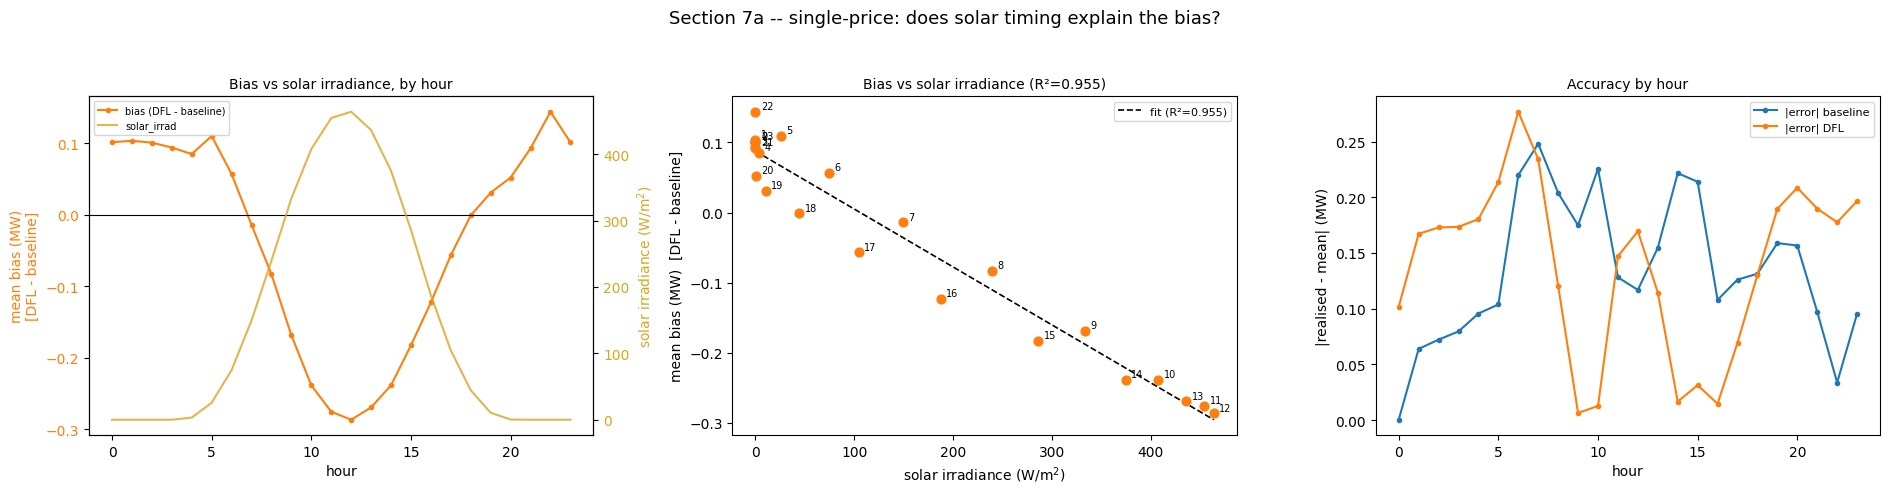

In [21]:
pd.set_option("display.width", 160)
single_solar_table = hourly_bias_solar_table(baseline_model, dfl_single, "baseline", "DFL")
display(single_solar_table.round(4))

plot_solar_bias_analysis(single_solar_table, "baseline", "DFL",
                          "Section 7a -- single-price: does solar timing explain the bias?")

In [22]:
single_r2_seeds = solar_r2_across_seeds("dfl_1stage_single-price")
print(f"single-price solar-bias R^2 across {len(SEEDS)} seeds: {single_r2_seeds.round(4).tolist()}")
print(f"  mean={single_r2_seeds.mean():.4f}  std={single_r2_seeds.std():.4f}  "
      f"min={single_r2_seeds.min():.4f}  max={single_r2_seeds.max():.4f}")

single-price solar-bias R^2 across 5 seeds: [0.9546, 0.9474, 0.0006, 0.0547, 0.4475]
  mean=0.4810  std=0.4136  min=0.0006  max=0.9546


### 7b -- dual-price

Same check as 7a, baseline vs DFL dual-price.

,realised,solar_irrad,mean_baseline,mean_DFL,bias,abs_err_baseline,abs_err_DFL
hour,,,,,,,
0,2.0180,0.0000,2.0184,2.0329,0.0145,0.0004,0.0149
1,1.8614,0.0000,1.9254,1.9320,0.0066,0.0640,0.0706
2,1.7538,0.0000,1.8260,1.8270,0.0010,0.0722,0.0732
3,1.6744,0.0000,1.7540,1.7481,-0.0059,0.0796,0.0737
4,1.6320,3.1761,1.7277,1.7133,-0.0144,0.0957,0.0813
5,1.7987,25.6564,1.9025,1.9105,0.0080,0.1038,0.1118
6,2.1707,74.6907,2.3906,2.3894,-0.0012,0.2199,0.2187
7,2.3567,149.4763,2.6048,2.5673,-0.0375,0.2481,0.2106
8,2.1967,239.6487,2.4006,2.3295,-0.0711,0.2038,0.1328


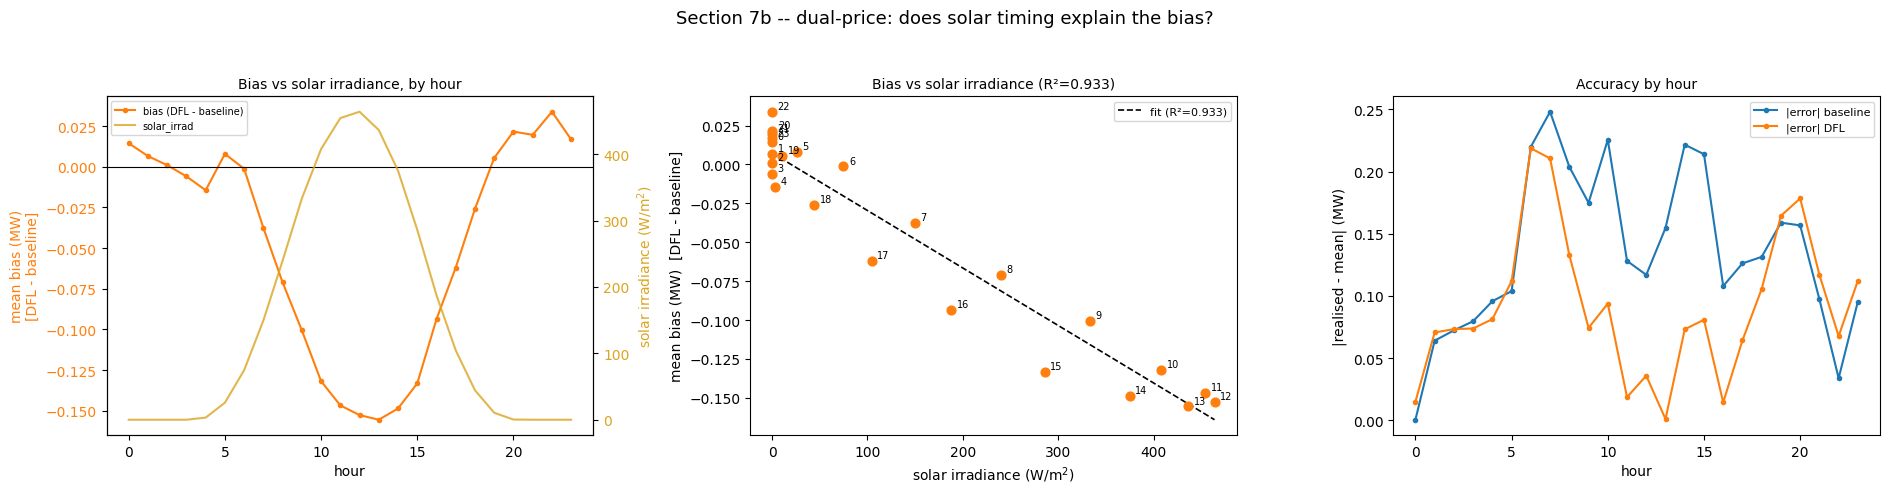

In [23]:
dual_solar_table = hourly_bias_solar_table(baseline_model, dfl_dual_balanced, "baseline", "DFL")
display(dual_solar_table.round(4))

plot_solar_bias_analysis(dual_solar_table, "baseline", "DFL",
                          "Section 7b -- dual-price: does solar timing explain the bias?")

In [24]:
dual_r2_seeds = solar_r2_across_seeds("dfl_1stage_dual-price")
print(f"dual-price solar-bias R^2 across {len(SEEDS)} seeds: {dual_r2_seeds.round(4).tolist()}")
print(f"  mean={dual_r2_seeds.mean():.4f}  std={dual_r2_seeds.std():.4f}  "
      f"min={dual_r2_seeds.min():.4f}  max={dual_r2_seeds.max():.4f}")

dual-price solar-bias R^2 across 5 seeds: [0.9329, 0.8734, 0.9123, 0.7992, 0.0132]
  mean=0.7062  std=0.3495  min=0.0132  max=0.9329


## Section 8 -- single-price DFL vs dual-price DFL, seasonal average

Prompted by the cross-evaluation check (`cross_price_eval.ipynb`): the dual-price-trained
"standard battery" forecaster run through the single-price dispatch pipeline comes out
close to -- trailing, but not far behind -- the forecaster actually trained for
single-price (native wins 57.1% of days vs cross-eval's 42.9%, mean cost 1741.95 vs
1744.39), while barely touching CRPS at all (0.267 vs baseline's 0.268, vs
single-price-trained's 0.291). This section visualises WHY that's plausible: do the two
DFL forecasters' seasonal-average shapes actually look similar?

Same style as Section 5 (15-85% band, seasonal average across every test day in each
season -- systematic shape, not a single-day snapshot), but comparing the two DFL
variants **directly against each other** instead of each against baseline:
`dfl_1stage_single-price` vs `dfl_1stage_dual-price` (the balanced/"standard battery"
checkpoint -- the same one used in the cross-evaluation). Both forecasters already loaded
(`dfl_single`, `dfl_dual_balanced`), no re-loading needed.

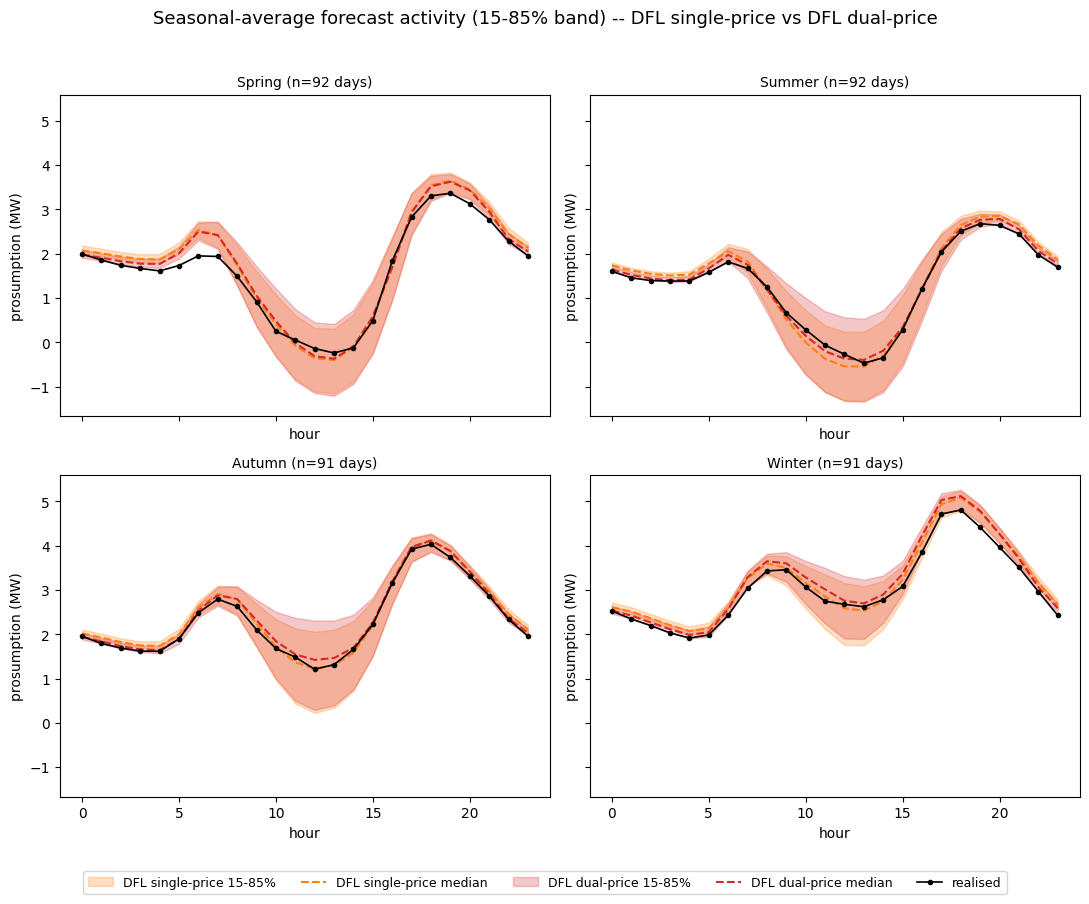

In [25]:
single_vs_dual_cells = []
for season in SEASON_ORDER:
    n_days = len(SEASON_DAY_INDICES[season])
    q_single_mean, y_mean = seasonal_average_quantiles(dfl_single, SEASON_DAY_INDICES[season])
    q_dual_mean, _ = seasonal_average_quantiles(dfl_dual_balanced, SEASON_DAY_INDICES[season])
    title = f"{season.capitalize()} (n={n_days} days)"
    single_vs_dual_cells.append((title, q_single_mean, q_dual_mean, y_mean))

plot_band_grid(single_vs_dual_cells, nrows=2, ncols=2,
               suptitle="Seasonal-average forecast activity (15-85% band) -- DFL single-price vs DFL dual-price",
               label_a="DFL single-price", label_b="DFL dual-price", color_a="C1", color_b="C3")

## Section 9 -- DFL single-price vs DFL dual-price: mean-median gap and solar-bias, compared directly

Section 8 showed the two DFL forecasters' seasonal-average *bands* look broadly similar.
This section applies Section 6/7's exact machinery -- but comparing the two DFL
forecasters **against each other** instead of each against baseline -- to check that
similarity precisely rather than by eye: do they sit at a similar mean-median gap, and
does the SAME solar-driven relationship hold when one is used as the reference for the
other? Reuses `seasonal_average_mean_median`, `plot_grid`, `hourly_bias_solar_table`,
`plot_solar_bias_analysis` unchanged -- only the pair of models being compared changes.

### 9a -- mean-median gap

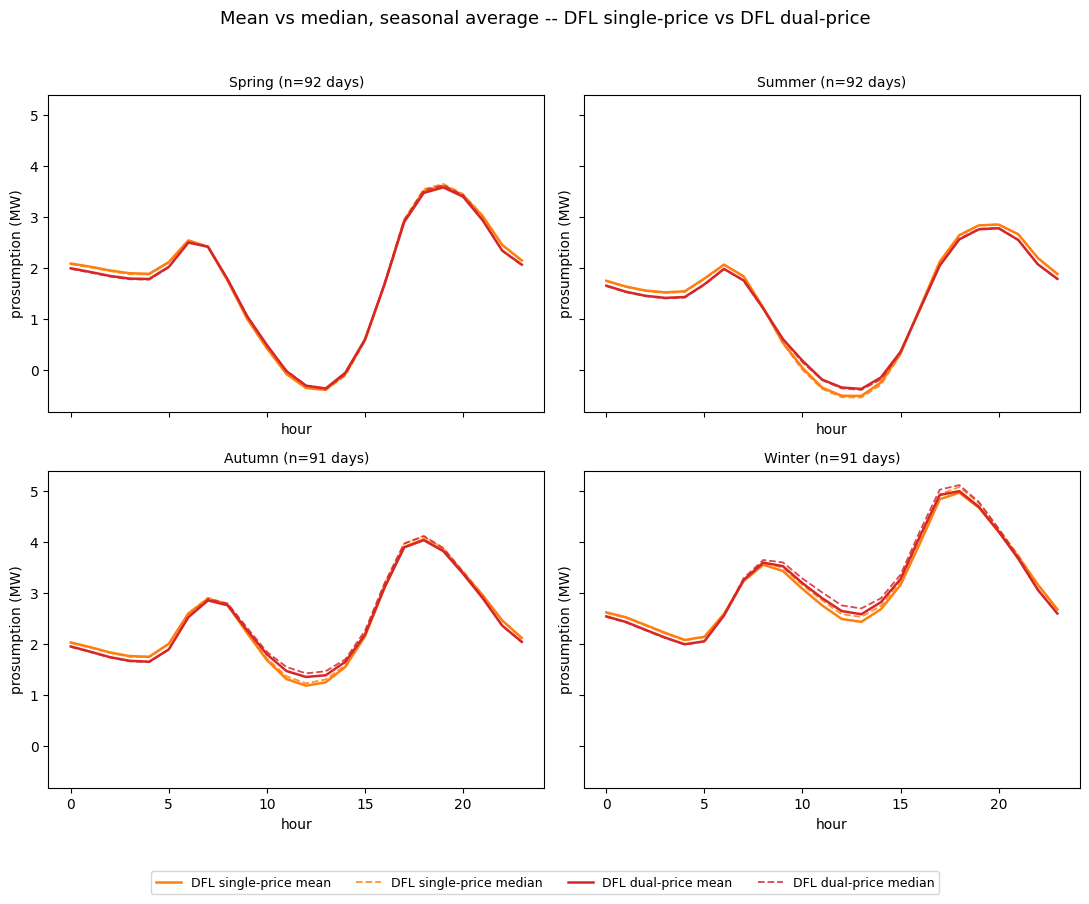

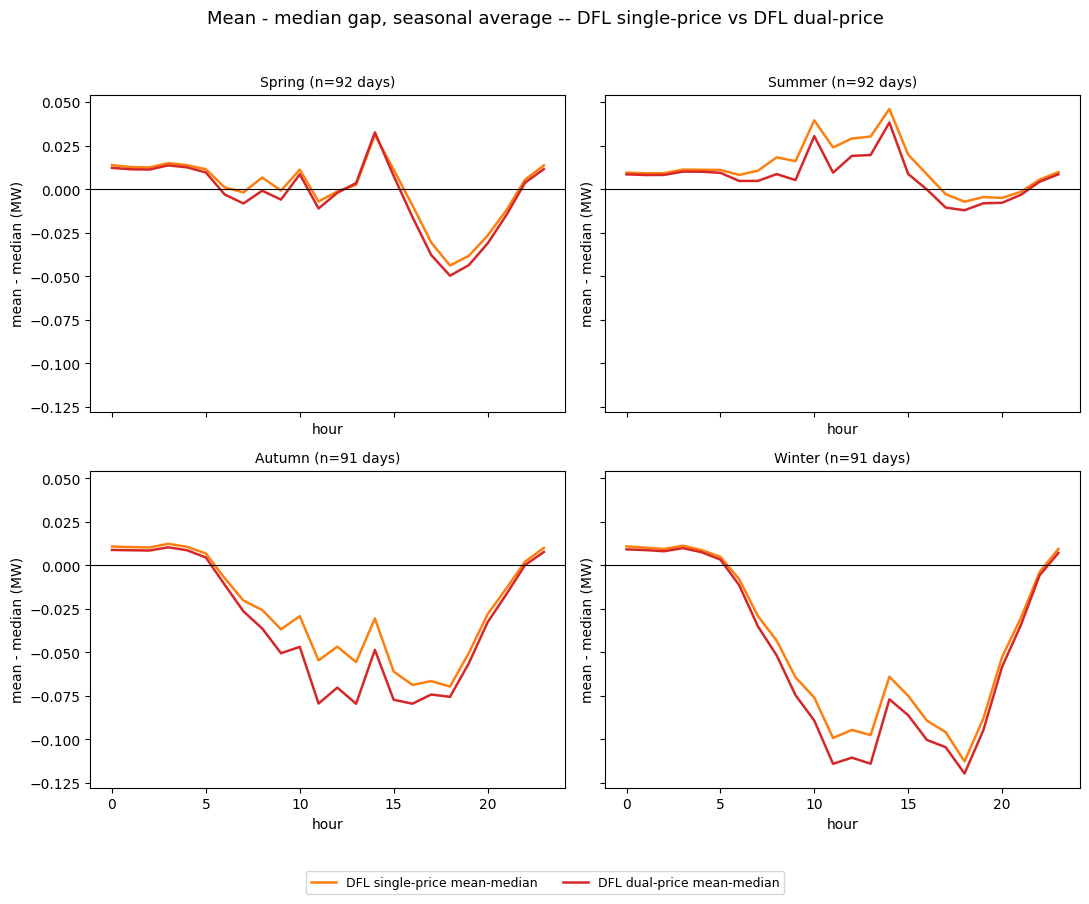

In [26]:
sd_mm_colors = {"DFL single-price": "C1", "DFL dual-price": "C3"}

sd_shape_cells, sd_gap_cells = [], []
for season in SEASON_ORDER:
    n_days = len(SEASON_DAY_INDICES[season])
    mean_single, median_single = seasonal_average_mean_median(dfl_single, SEASON_DAY_INDICES[season])
    mean_dual, median_dual = seasonal_average_mean_median(dfl_dual_balanced, SEASON_DAY_INDICES[season])

    data = {"DFL single-price": (mean_single, median_single), "DFL dual-price": (mean_dual, median_dual)}
    title = f"{season.capitalize()} (n={n_days} days)"
    sd_shape_cells.append((title, data))
    sd_gap_cells.append((title, data))

plot_grid(plot_mean_median_shape, sd_shape_cells, nrows=2, ncols=2,
          suptitle="Mean vs median, seasonal average -- DFL single-price vs DFL dual-price", colors=sd_mm_colors)
plot_grid(plot_mean_median_gap, sd_gap_cells, nrows=2, ncols=2,
          suptitle="Mean - median gap, seasonal average -- DFL single-price vs DFL dual-price", colors=sd_mm_colors)

### 9b -- solar-bias, DFL single-price as reference

`bias = mean_{DFL dual-price} - mean_{DFL single-price}` -- if the two forecasters learned
essentially the same solar-driven correction (as Section 8's band similarity and the
cross-eval near-tie both suggest), this bias-vs-solar_irrad relationship should be much
FLATTER / lower-R² than Section 7's baseline-referenced versions -- there'd be little
SOLAR-CORRELATED daylight left between two forecasters that both already made the same
correction. The `|error|` panel also becomes a direct single-vs-dual accuracy comparison,
hour by hour.

,realised,solar_irrad,mean_DFL single-price,mean_DFL dual-price,bias,abs_err_DFL single-price,abs_err_DFL dual-price
hour,,,,,,,
0,2.0180,0.0000,2.1197,2.0329,-0.0868,0.1017,0.0149
1,1.8614,0.0000,2.0286,1.9320,-0.0966,0.1672,0.0706
2,1.7538,0.0000,1.9267,1.8270,-0.0997,0.1729,0.0732
3,1.6744,0.0000,1.8478,1.7481,-0.0997,0.1735,0.0737
4,1.6320,3.1761,1.8125,1.7133,-0.0991,0.1804,0.0813
5,1.7987,25.6564,2.0124,1.9105,-0.1019,0.2137,0.1118
6,2.1707,74.6907,2.4474,2.3894,-0.0581,0.2768,0.2187
7,2.3567,149.4763,2.5908,2.5673,-0.0235,0.2340,0.2106
8,2.1967,239.6487,2.3173,2.3295,0.0122,0.1206,0.1328


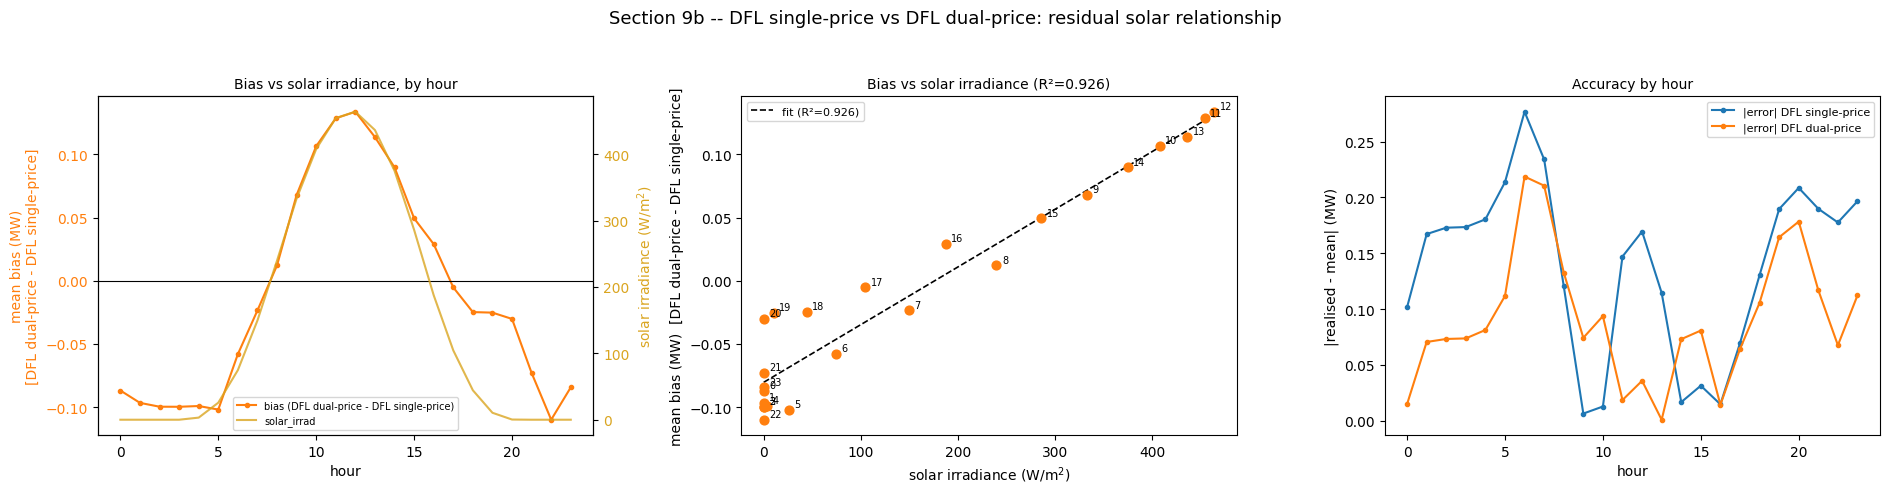

In [27]:
single_vs_dual_table = hourly_bias_solar_table(dfl_single, dfl_dual_balanced, "DFL single-price", "DFL dual-price")
display(single_vs_dual_table.round(4))

plot_solar_bias_analysis(single_vs_dual_table, "DFL single-price", "DFL dual-price",
                          "Section 9b -- DFL single-price vs DFL dual-price: residual solar relationship")

## Section 10 -- accuracy per hour (MAE), baseline vs DFL

A genuinely different metric from Sections 6-9's "bias" columns, worth being precise
about: this is `mean(|realised - mean|)` -- average the ABSOLUTE error per day, THEN
average across days -- not `|mean(realised) - mean(mean)|` (average first, then take the
absolute value), which is what `hourly_bias_solar_table`'s `abs_err` columns compute. By
Jensen's inequality `mean(|e|) >= |mean(e)|` always, so this MAE is a genuine typical-error
magnitude (won't hide same-day cancellation the way the bias-style abs_err can) --
appropriate for an "accuracy" question specifically, as opposed to a "systematic bias"
one.

For each market (single-price, dual-price): a seasonal 2x2 grid (baseline vs that
market's DFL, per season) plus one standalone graph with both lines over the FULL test
year (not per season) -- baseline's overall MAE is computed once and shared between both
markets' overall graphs.

In [28]:
def hourly_mae(model, day_indices):
    """Mean ABSOLUTE ERROR by hour-of-day: |realised - mean| computed per day, then
    averaged across days -- see Section 10's markdown for why this differs from the
    bias-style abs_err columns elsewhere in this notebook."""
    errs = []
    for d in day_indices:
        q = forecast_quantiles(model, sc, windows.x_hist[d], windows.x_fut[d])
        mean, _ = sampler.mean_and_errors(q)
        mean = mean.detach().cpu().numpy()
        realised = np.asarray(windows.y[d], float)
        errs.append(np.abs(realised - mean))
    return np.mean(errs, axis=0)   # (24,)


def plot_accuracy_by_hour(ax, forecaster_data, colors, title=""):
    """forecaster_data: {label: mae (24,) array}."""
    for label, mae in forecaster_data.items():
        ax.plot(np.arange(len(mae)), mae, "-o", color=colors[label], markersize=3,
                 label=label, linewidth=1.6)
    ax.set_xlabel("hour")
    ax.set_ylabel("MAE (MW)")
    if title:
        ax.set_title(title, fontsize=10)


def metric_across_seeds(metric_fn, base_id, day_indices=None):
    """metric_fn: hourly_mae or hourly_bias_own. Loads all 5 seeds of base_id (see
    Section 7's SEEDS/seed_variant), applies metric_fn to each, returns
    (mean_by_hour (24,), std_by_hour (24,)) across the 5 seeds -- the multi-seed
    analogue of Section 10c/10d's single-checkpoint lines."""
    days = ALL_DAYS if day_indices is None else day_indices
    vals = np.array([metric_fn(load_dfl(seed_variant(base_id, seed)), days) for seed in SEEDS])
    return vals.mean(axis=0), vals.std(axis=0)


ALL_DAYS = range(len(windows.delivery_start))
mae_base_overall = hourly_mae(baseline_model, ALL_DAYS)
print("overall baseline MAE by hour computed (shared by 10a/10b's overall graphs)")

overall baseline MAE by hour computed (shared by 10a/10b's overall graphs)


### 10a -- single-price

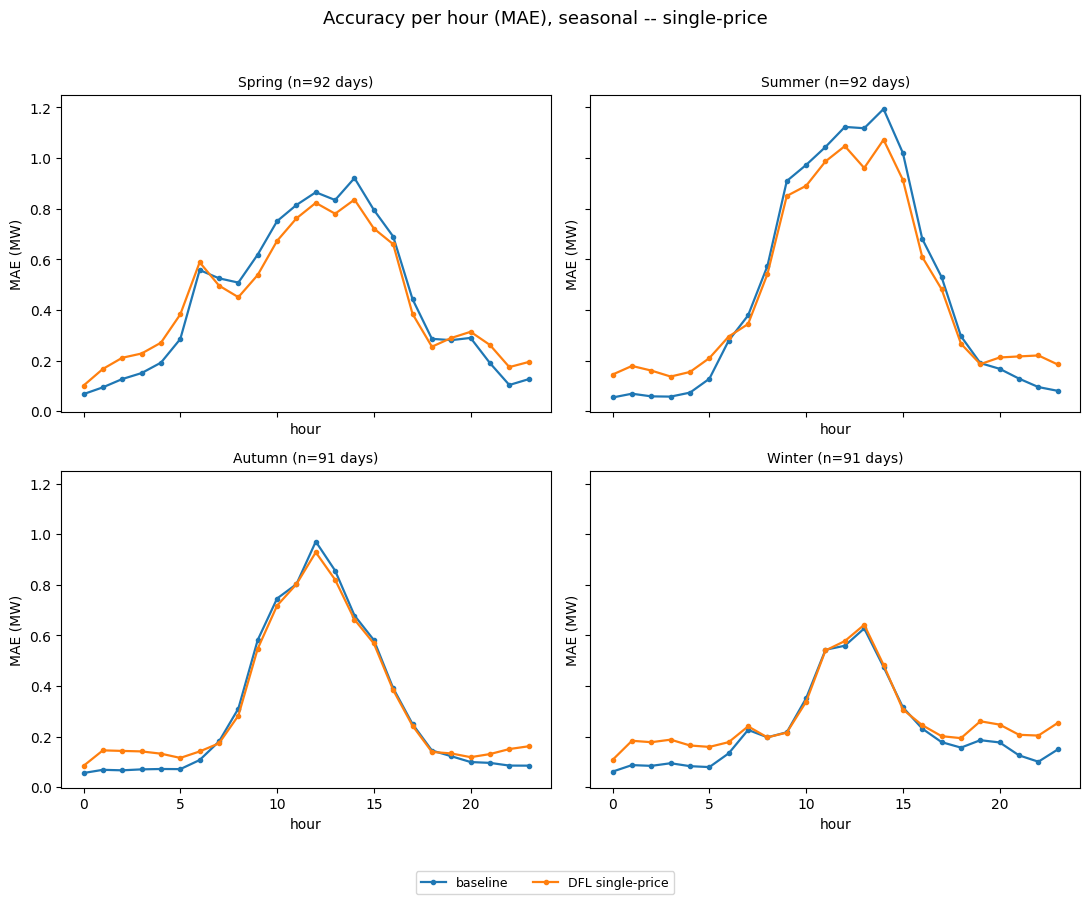

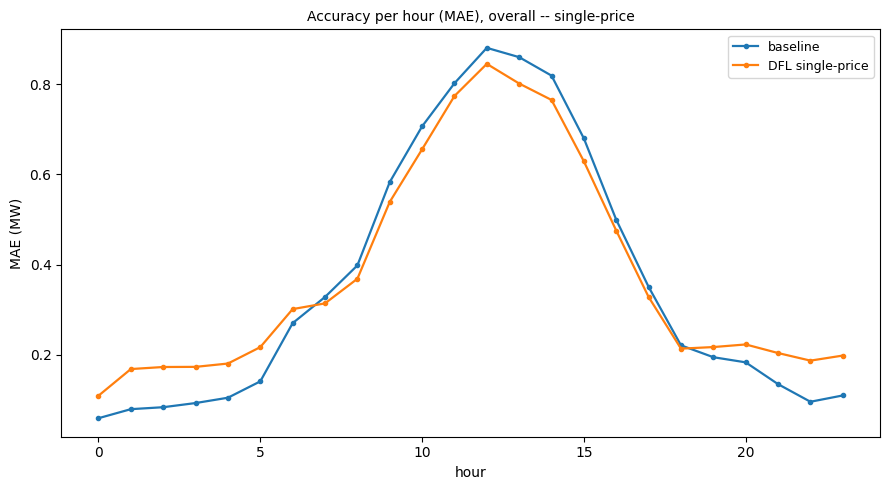

In [29]:
single_mae_cells = []
for season in SEASON_ORDER:
    n_days = len(SEASON_DAY_INDICES[season])
    mae_base_s = hourly_mae(baseline_model, SEASON_DAY_INDICES[season])
    mae_dfl_s = hourly_mae(dfl_single, SEASON_DAY_INDICES[season])
    data = {"baseline": mae_base_s, "DFL single-price": mae_dfl_s}
    single_mae_cells.append((f"{season.capitalize()} (n={n_days} days)", data))

plot_grid(plot_accuracy_by_hour, single_mae_cells, nrows=2, ncols=2,
          suptitle="Accuracy per hour (MAE), seasonal -- single-price", colors=single_mm_colors)

mae_single_overall = hourly_mae(dfl_single, ALL_DAYS)
fig, ax = plt.subplots(figsize=(9, 5))
plot_accuracy_by_hour(ax, {"baseline": mae_base_overall, "DFL single-price": mae_single_overall},
                       single_mm_colors, title="Accuracy per hour (MAE), overall -- single-price")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### 10b -- dual-price

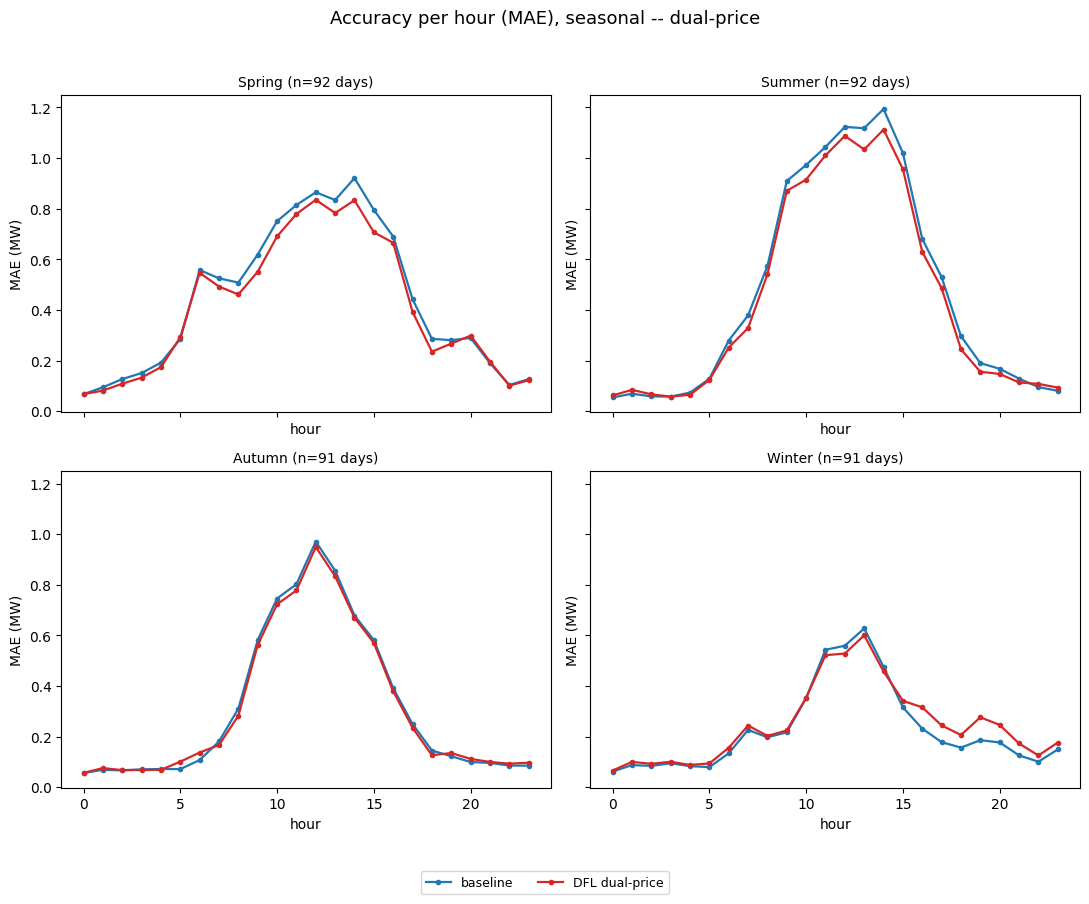

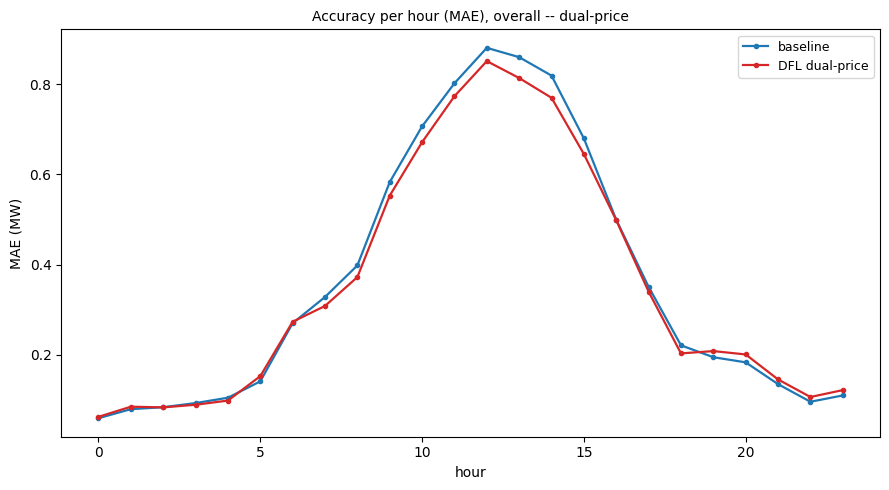

In [30]:
dual_mae_colors = {"baseline": "C0", "DFL dual-price": "C3"}

dual_mae_cells = []
for season in SEASON_ORDER:
    n_days = len(SEASON_DAY_INDICES[season])
    mae_base_s = hourly_mae(baseline_model, SEASON_DAY_INDICES[season])
    mae_dfl_s = hourly_mae(dfl_dual_balanced, SEASON_DAY_INDICES[season])
    data = {"baseline": mae_base_s, "DFL dual-price": mae_dfl_s}
    dual_mae_cells.append((f"{season.capitalize()} (n={n_days} days)", data))

plot_grid(plot_accuracy_by_hour, dual_mae_cells, nrows=2, ncols=2,
          suptitle="Accuracy per hour (MAE), seasonal -- dual-price", colors=dual_mae_colors)

mae_dual_overall = hourly_mae(dfl_dual_balanced, ALL_DAYS)
fig, ax = plt.subplots(figsize=(9, 5))
plot_accuracy_by_hour(ax, {"baseline": mae_base_overall, "DFL dual-price": mae_dual_overall},
                       dual_mae_colors, title="Accuracy per hour (MAE), overall -- dual-price")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### 10c -- complete comparison, one row per forecaster (baseline vs each retrained model)

Same 5-seed mean +/- std treatment as before, but split into three side-by-side panels --
baseline vs CRPS-only control, baseline vs DFL single-price, baseline vs DFL dual-price --
rather than four series overlaid on one axis. All three panels in the row share the same
y-axis (so a wide band in one panel is directly comparable to a narrow one in another) and
carry the same horizontal reference gridlines, making cross-panel magnitude comparison
possible without re-reading each axis. This is the direct visual analogue of Q1's
`pct_change_min`/`pct_change_max` columns in `aggregate_results.ipynb`: if a shaded band is
wide relative to its gap from baseline, the "control tracks baseline / single oscillates /
dual is intermediate" shape story from earlier in this notebook was itself a single-seed
read, not a stable finding.

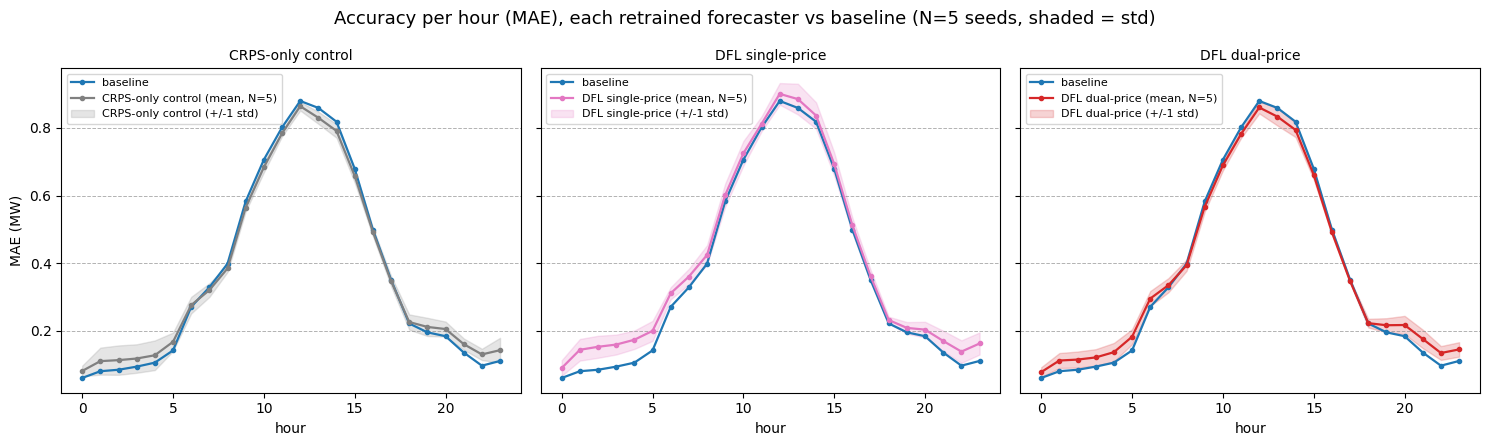

In [31]:
comparison_mae_colors = {"baseline": "C0", "CRPS-only control": "grey", "DFL single-price": "C6", "DFL dual-price": "C3"}


def plot_metric_row(baseline_series, panels, colors, ylabel, fig_title, zero_line=False):
    """One row of len(panels) subplots, sharing the y-axis, each comparing the fixed
    baseline_series (24,) against one seed-averaged forecaster.
    panels: list of (label, mean (24,), std (24,)) tuples, one per subplot.
    Horizontal gridlines (shared across the row via sharey) make magnitudes directly
    comparable panel-to-panel, not just within a single panel."""
    h = np.arange(24)
    fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 4.5), sharey=True)
    for ax, (label, mean, std) in zip(axes, panels):
        ax.plot(h, baseline_series, "-o", color=colors["baseline"], markersize=3,
                 label="baseline", linewidth=1.6)
        ax.plot(h, mean, "-o", color=colors[label], markersize=3,
                 label=f"{label} (mean, N=5)", linewidth=1.6)
        ax.fill_between(h, mean - std, mean + std, color=colors[label], alpha=0.2,
                          label=f"{label} (+/-1 std)")
        if zero_line:
            ax.axhline(0, color="black", linewidth=0.9, zorder=2)
        ax.grid(axis="y", linestyle="--", linewidth=0.7, color="grey", alpha=0.6, zorder=0)
        ax.set_xlabel("hour")
        ax.set_title(label, fontsize=10)
        ax.legend(fontsize=8, loc="best")
    axes[0].set_ylabel(ylabel)
    fig.suptitle(fig_title, fontsize=13)
    fig.tight_layout()
    return fig, axes


mae_crps_only_mean, mae_crps_only_std = metric_across_seeds(hourly_mae, "crps_only_retrained")
mae_single_mean, mae_single_std = metric_across_seeds(hourly_mae, "dfl_1stage_single-price")
mae_dual_mean, mae_dual_std = metric_across_seeds(hourly_mae, "dfl_1stage_dual-price")

fig, axes = plot_metric_row(
    mae_base_overall,
    [("CRPS-only control", mae_crps_only_mean, mae_crps_only_std),
     ("DFL single-price", mae_single_mean, mae_single_std),
     ("DFL dual-price", mae_dual_mean, mae_dual_std)],
    comparison_mae_colors, ylabel="MAE (MW)",
    fig_title="Accuracy per hour (MAE), each retrained forecaster vs baseline (N=5 seeds, shaded = std)")
plt.show()

### 10d -- forecast bias per hour (signed), same layout as 10c

Companion to 10c, not a replacement: MAE (10c) is `mean(|realised - mean|)` -- always
positive, tells you HOW WRONG each forecaster is at each hour but not which direction.
This is `mean(mean - realised)` -- SIGNED, each forecaster's own systematic bias (not a
delta between forecasters, and not absolute-valued) -- **positive means over-predicting**
on average at that hour (forecast too high), **negative means under-predicting** (forecast
too low). Worth checking directly against 10c's observation: a forecaster can be MORE
biased at an hour while still being more (or less) accurate there overall, if its
variance/spread also changed -- bias and MAE aren't forced to move together.

Same three-panel, shared-y-axis, gridlined layout as 10c, plus a solid zero line (the
natural reference for a signed quantity) on every panel.

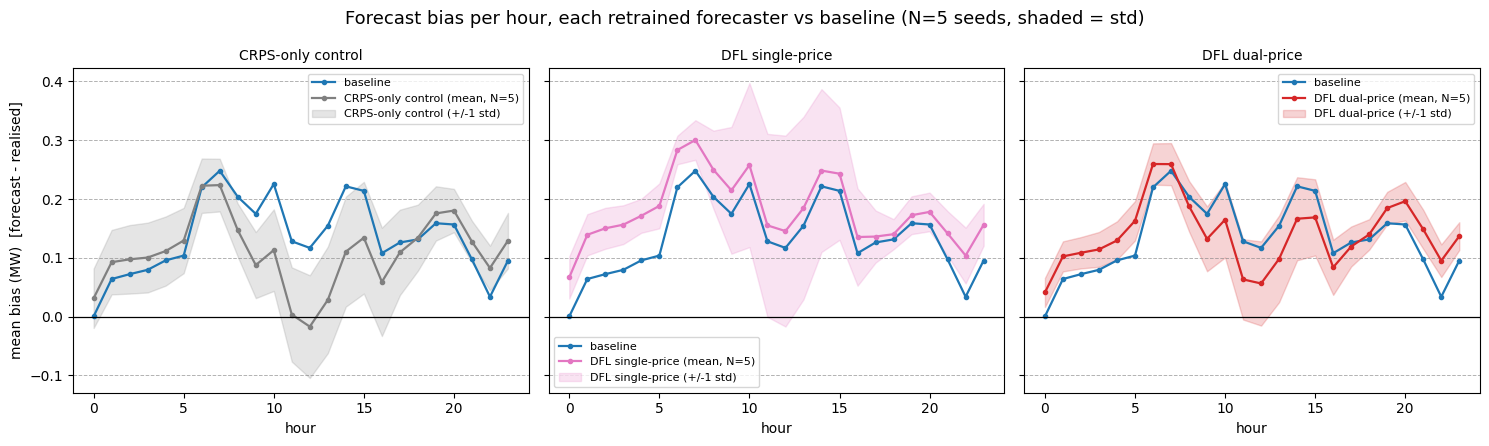

In [32]:
def hourly_bias_own(model, day_indices):
    """Mean SIGNED error by hour-of-day: (mean - realised) computed per day, then
    averaged across days -- each forecaster's own bias, not a delta between forecasters
    (contrast with hourly_bias_solar_table's 'bias' column) and not absolute-valued
    (contrast with hourly_mae). Positive = forecaster predicts too much (over-predicts),
    negative = forecaster predicts too little (under-predicts)."""
    errs = []
    for d in day_indices:
        q = forecast_quantiles(model, sc, windows.x_hist[d], windows.x_fut[d])
        mean, _ = sampler.mean_and_errors(q)
        mean = mean.detach().cpu().numpy()
        realised = np.asarray(windows.y[d], float)
        errs.append(mean - realised)
    return np.mean(errs, axis=0)   # (24,)


bias_base_overall = hourly_bias_own(baseline_model, ALL_DAYS)
bias_crps_only_mean, bias_crps_only_std = metric_across_seeds(hourly_bias_own, "crps_only_retrained")
bias_single_mean, bias_single_std = metric_across_seeds(hourly_bias_own, "dfl_1stage_single-price")
bias_dual_mean, bias_dual_std = metric_across_seeds(hourly_bias_own, "dfl_1stage_dual-price")

fig, axes = plot_metric_row(
    bias_base_overall,
    [("CRPS-only control", bias_crps_only_mean, bias_crps_only_std),
     ("DFL single-price", bias_single_mean, bias_single_std),
     ("DFL dual-price", bias_dual_mean, bias_dual_std)],
    comparison_mae_colors, ylabel="mean bias (MW)  [forecast - realised]",
    fig_title="Forecast bias per hour, each retrained forecaster vs baseline (N=5 seeds, shaded = std)",
    zero_line=True)
plt.show()